# Post mofa-flex analysis

### Contents:

1. [Load models (Normal, SnS, and GP).](#load-models)

2. [MOFA-Flex model result overview.](#mofa-flex-results-overview)
<br>
2.1 [Factor correlation and variance explained.](#1-variance-explained)
<br>
2.2 [Average R2.](#2-average-r2)
<br>
2.3 [Weights distribution.](#3weights-dist)
<br>
2.4 [Heatmap (view x LR).](#4-heatmap-view-x-lr)

3. [DR and clustering.](#dr-using-factors-values)

4. [Regression Model.](#regression-model)
<br>
4.1 [Evaluate model.](#evaluate-the-model)
<br>
4.2 [AUC.](#auc)

5. [Map clusters to spatial.](#map-clusters-to-spatial)

In [1]:
import os.path
import anndata as ad
import mudata as md
import numpy as np
import pandas as pd
import mofaflex as mfl
from plotnine import *
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
from umap import UMAP
from sklearn.manifold import TSNE

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



# Run MOFA

## Read mdata

In [ ]:
mdata_path = Path("/g/stegle/aalsayah/repos/data/merfish/mouse_brain/mudata")

In [ ]:
mdata = md.read(mdata_path / "WB_MERFISH_animal2_coronal_mudata.h5mu")

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.


In [ ]:
del mdata.mod["glycinergic_neuron"]
del mdata.mod["monocyte"]
# del mdata.mod["histaminergic_neuron"]
del mdata.mod["dopaminergic_neuron"]
del mdata.mod["dendritic_cell"]
#del mdata.mod["cholinergic_neuron"]
del mdata.mod["macrophage"]
del mdata.mod["lymphocyte"]
# del mdata.mod["smooth_muscle_cell"]
del mdata.mod["pericyte"]
del mdata.mod["tanycyte"]

In [ ]:
import mudata as mu
mdata_new = mu.MuData({mod: ad for mod, ad in mdata.mod.items()})

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.


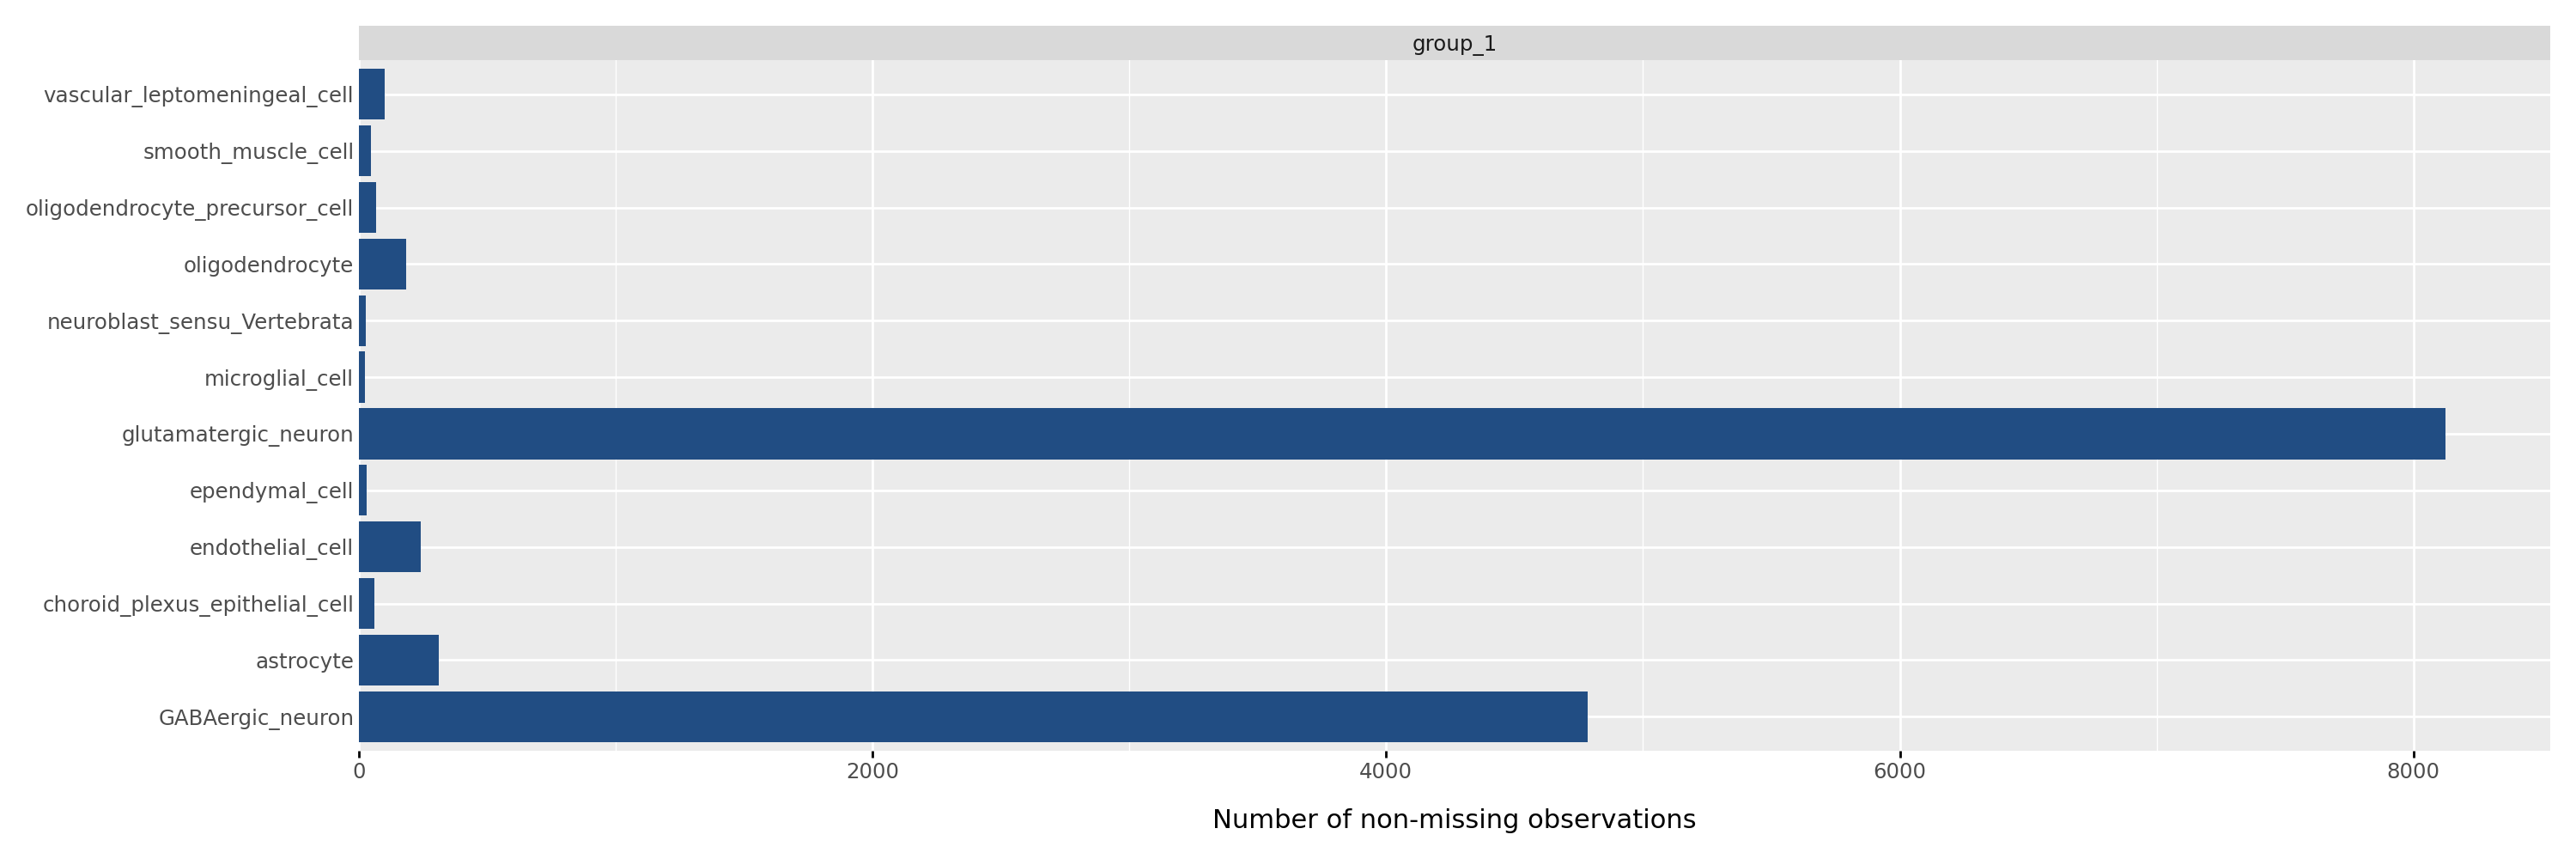

WARNING	Sparse arrays are currently not supported by Dask. Dask will not be used and data arrays may be copied, resulting in high memory usage.
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site

INFO	Initializing factors using `random` method...


  0%|                                                        | 0/1000 [00:00<?, ?epochs/s]

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/linear_operator/utils/interpolation.py:71: UserWarning: The torch.cuda.*DtypeTensor constructors are no longer recommended. It's best to use methods such as torch.tensor(data, dtype=*, device='cuda') to create tensors. (Triggered internally at /pytorch/torch/csrc/tensor/python_tensor.cpp:78.)
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/linear_operator/utils/interpolation.py:71: UserWarning: torch.sparse.SparseTensor(indices, values, shape, *, device=) is deprecated.  Please use torch.sparse_coo_tensor(indices, values, shape, dtype=, device=). (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:653.)
INFO	Training converged after 551 epochs.
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_opti

In [6]:
model = mfl.MOFAFLEX(
    mdata_new,
    mfl.DataOptions(covariates_obsm_key="X_spatial_coords"),
    mfl.ModelOptions(
        n_factors=10,
        factor_prior="GP",
        likelihoods="Normal",
        weight_prior="SnS",
        nonnegative_factors=True,
        nonnegative_weights=True
    ),
    mfl.TrainingOptions(
        batch_size=2000,
        n_particles=10,
        lr=0.005,
        max_epochs=1000,
        save_path=str("/g/stegle/aalsayah/repos/data/merfish/mouse_brain/mofa_models/WB_MERFISH_animal2_coronal_GP_SnS2.hdf5"),
        early_stopper_patience=50,
    ),
)

# Load models

### Normal

In [7]:
models_path = Path("/g/stegle/aalsayah/repos/data/merfish/mouse_brain/mofa_models")

In [8]:
model= mfl.MOFAFLEX.load(models_path / "WB_MERFISH_animal2_coronal_GP_SnS.hdf5")

In [9]:
from plotnine.ggplot import ggplot  # to check object type

def evaluate_single_mofa_model(model, output_dir=None, group="group_1", show_plots=True):
    """
    Evaluate a single trained MOFAFLEX model.
    Handles both plotnine (ggplot) and matplotlib plots.
    """
    if output_dir:
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)

    results = {}

    # --- Factor correlation ---
    print("Plotting factor correlation...")
    fig1 = mfl.pl.factor_correlation(model)
    if output_dir:
        fc_path = output_dir / "factor_correlation.png"
        if isinstance(fig1, ggplot):
            fig1.save(fc_path, dpi=300)
        else:
            fig1.savefig(fc_path, bbox_inches="tight")
        results["factor_correlation_path"] = str(fc_path)
    if show_plots:
        print(fig1)
    else:
        plt.close('all')

    # --- quality control for SnS priors ---
    print("Plotting weight_sparsity_histogram (QC for SnS priors)...")
    fig1 = mfl.pl.weight_sparsity_histogram(model)
    if output_dir:
        fc_path = output_dir / "weight_sparsity_histogram.png"
        if isinstance(fig1, ggplot):
            fig1.save(fc_path, dpi=300)
        else:
            fig1.savefig(fc_path, bbox_inches="tight")
        results["weight_sparsity_histogram_path"] = str(fc_path)
    if show_plots:
        print(fig1)
    else:
        plt.close('all')

    # --- Variance explained ---
    print("Plotting variance explained...")
    fig2 = mfl.pl.variance_explained(model, figsize=(8, 8))
    if output_dir:
        ve_path = output_dir / "variance_explained.png"
        if isinstance(fig2, ggplot):
            fig2.save(ve_path, dpi=300)
        else:
            fig2.savefig(ve_path, bbox_inches="tight")
        results["variance_explained_path"] = str(ve_path)
    if show_plots:
        print(fig2)
    else:
        plt.close('all')

    # --- Compute R² ---
    print("Computing R²...")
    r2 = model.get_r2(total=True)
    mean_r2 = float(r2[group].mean())
    results["mean_r2"] = mean_r2
    print(f"✅ Mean R² for {group}: {mean_r2:.4f}")

    # --- Save metrics file ---
    if output_dir:
        metrics_path = output_dir / "metrics.txt"
        with open(metrics_path, "w") as f:
            f.write(f"Mean R² ({group}): {mean_r2:.4f}\n")
        results["metrics_path"] = str(metrics_path)

    return results


Plotting factor correlation...


/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 8 x 8 in image.
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: /g/stegle/aalsayah/repos/data/merfish/mouse_brain/mofa_models/evaluation_results/factor_correlation.png
/scratch/jobs/42544207/ipykernel_1522167/655630245.py:25: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().


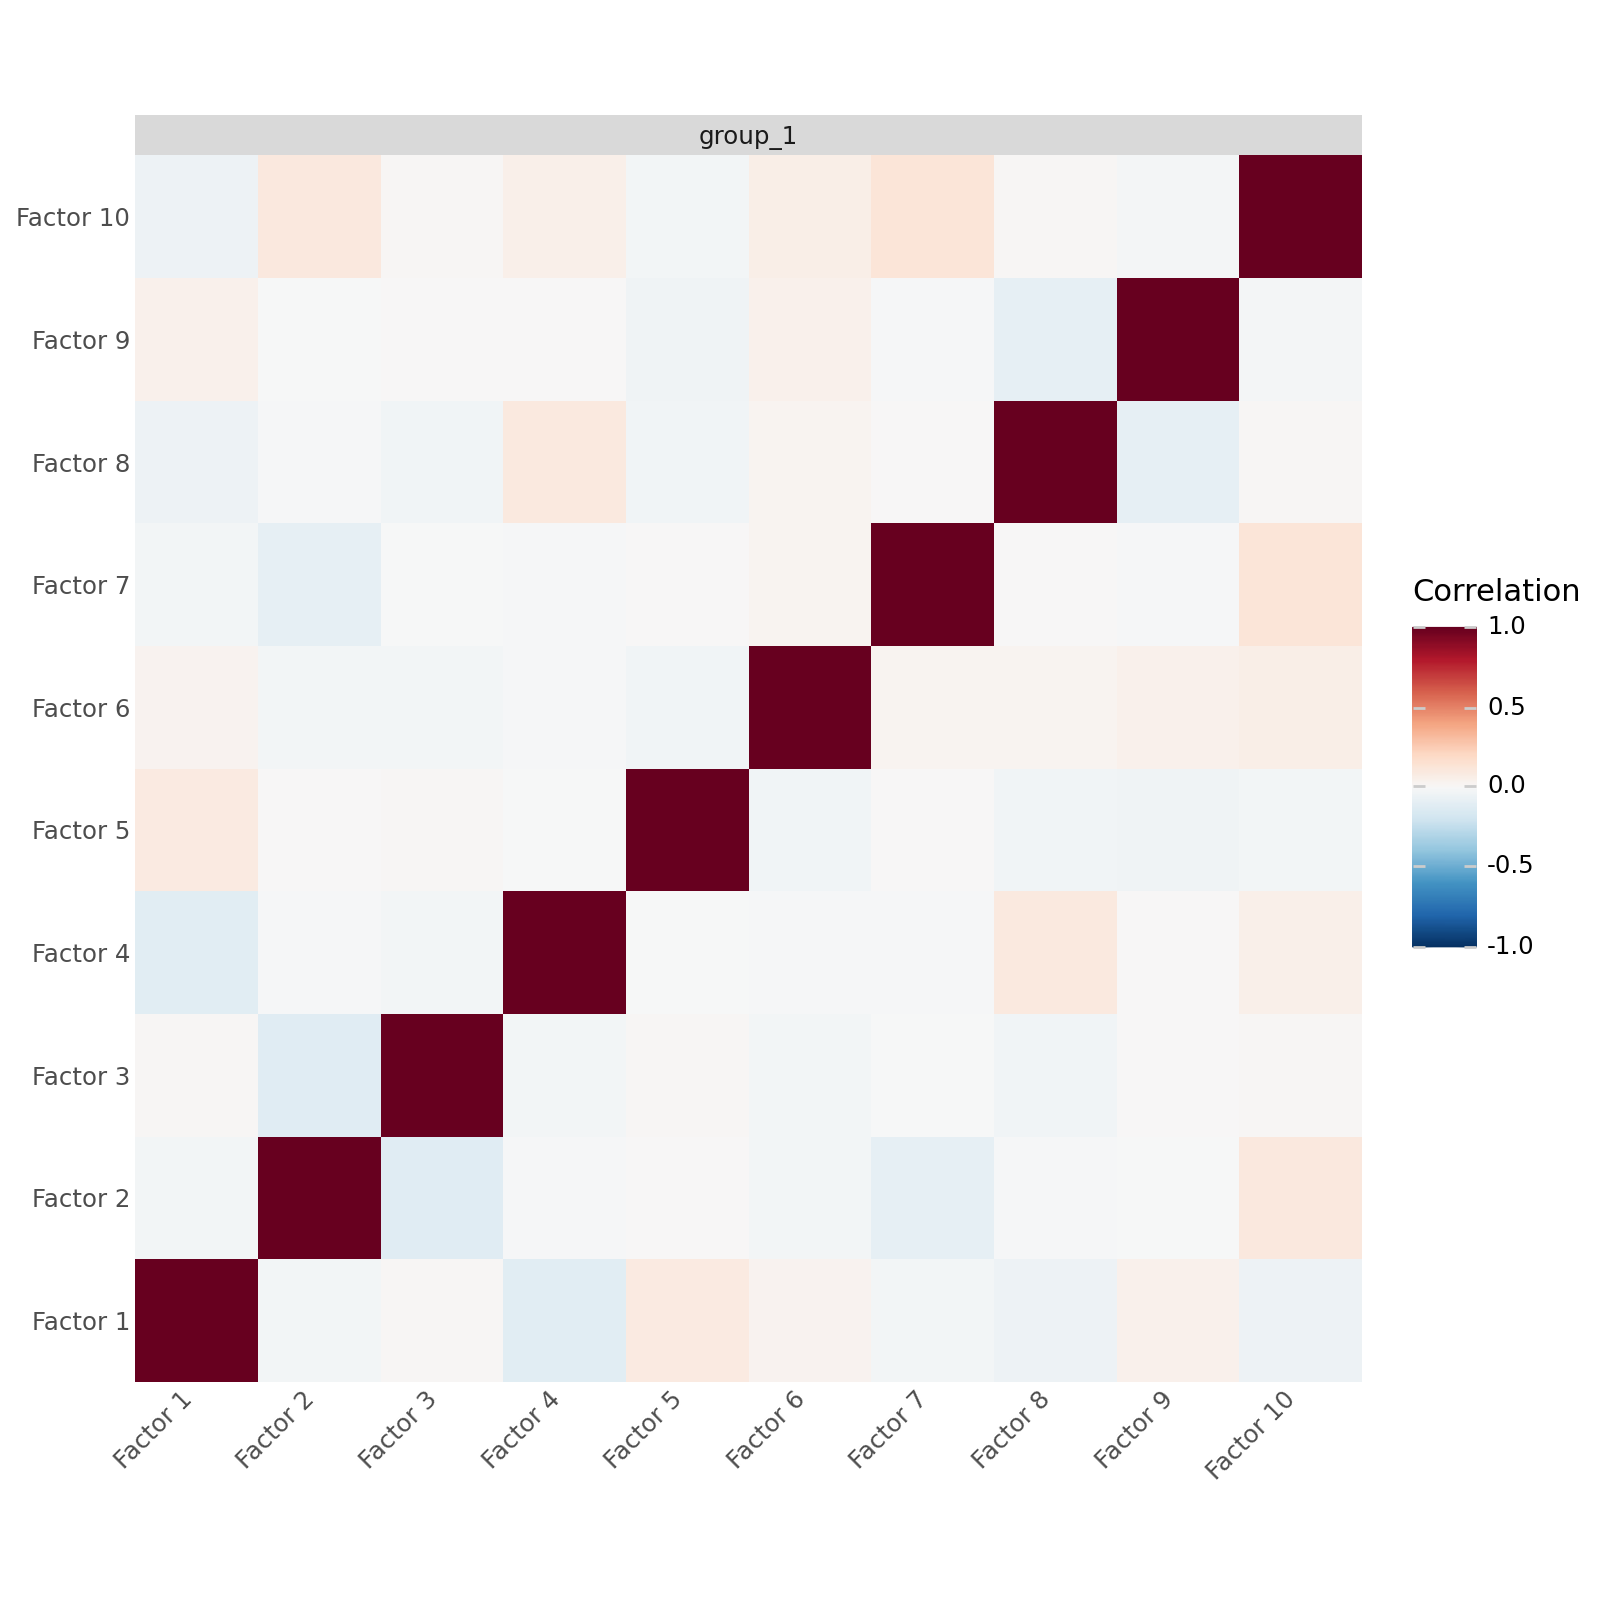


Plotting weight_sparsity_histogram (QC for SnS priors)...


/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 6.4 x 4.8 in image.
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: /g/stegle/aalsayah/repos/data/merfish/mouse_brain/mofa_models/evaluation_results/weight_sparsity_histogram.png
/scratch/jobs/42544207/ipykernel_1522167/655630245.py:40: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().


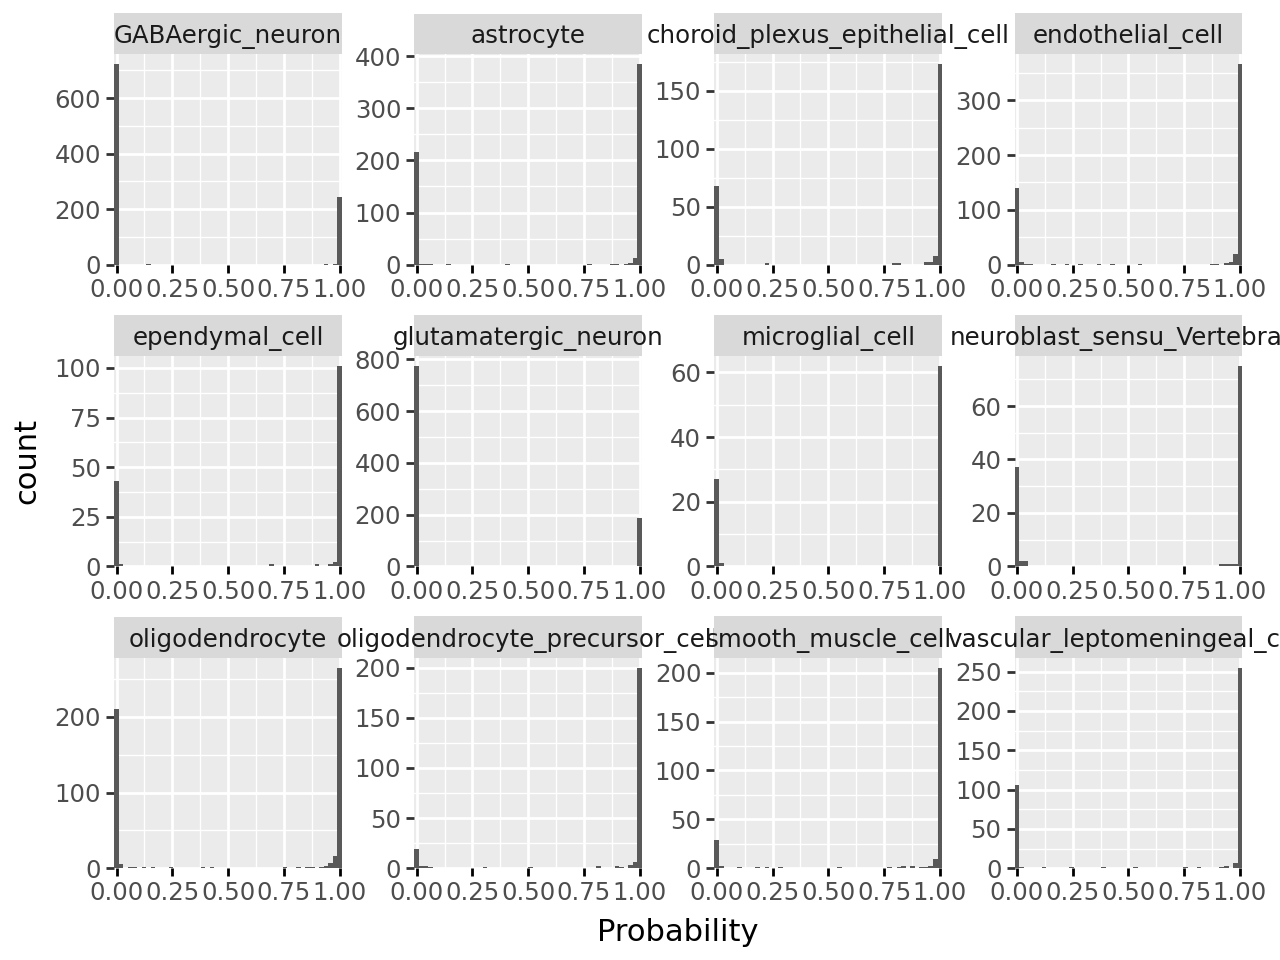


Plotting variance explained...


/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 8 x 8 in image.
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: /g/stegle/aalsayah/repos/data/merfish/mouse_brain/mofa_models/evaluation_results/variance_explained.png
/scratch/jobs/42544207/ipykernel_1522167/655630245.py:55: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().


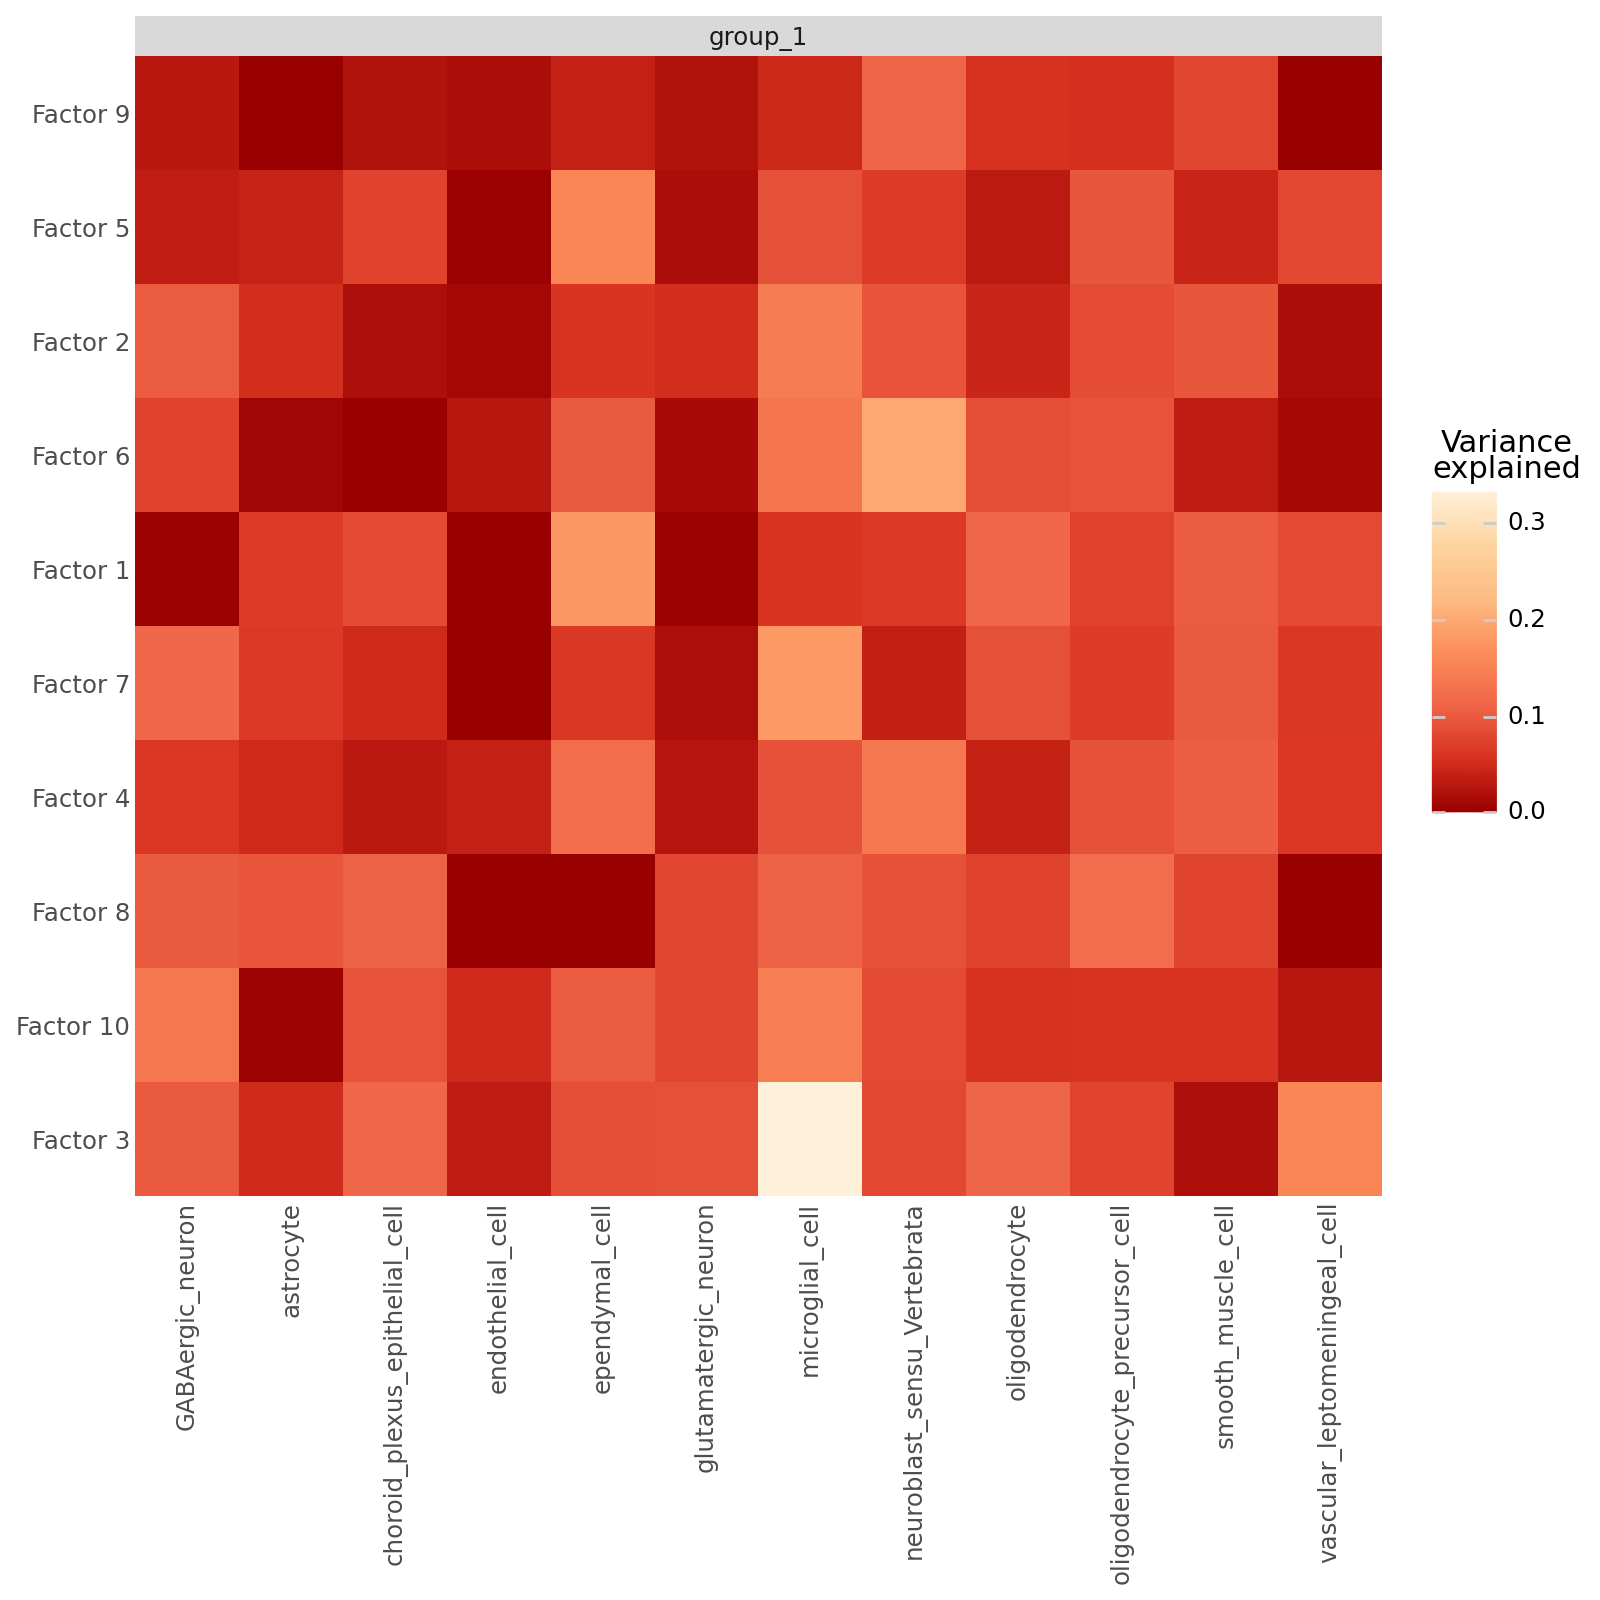


Computing R²...
✅ Mean R² for group_1: 0.7274


In [10]:
results = evaluate_single_mofa_model(model, output_dir="/g/stegle/aalsayah/repos/data/merfish/mouse_brain/mofa_models/evaluation_results", group="group_1", show_plots=True)


### SnS

In [2]:
model = mfl.MOFAFLEX.load("/g/stegle/aalsayah/repos/data/merfish/mofa_model_Normal_SnS_animal2_C57BL6J-2.039.hdf5")

### GP

In [ ]:
#model = mfl.MOFAFLEX.load(models_path / "GP_models/crc_232_no_mye_IgM/GP.Normal/crc_232_no_mye_IgM.GP.Normal.hdf5")

# MOFA-Flex results overview

## 1. Variance Explained

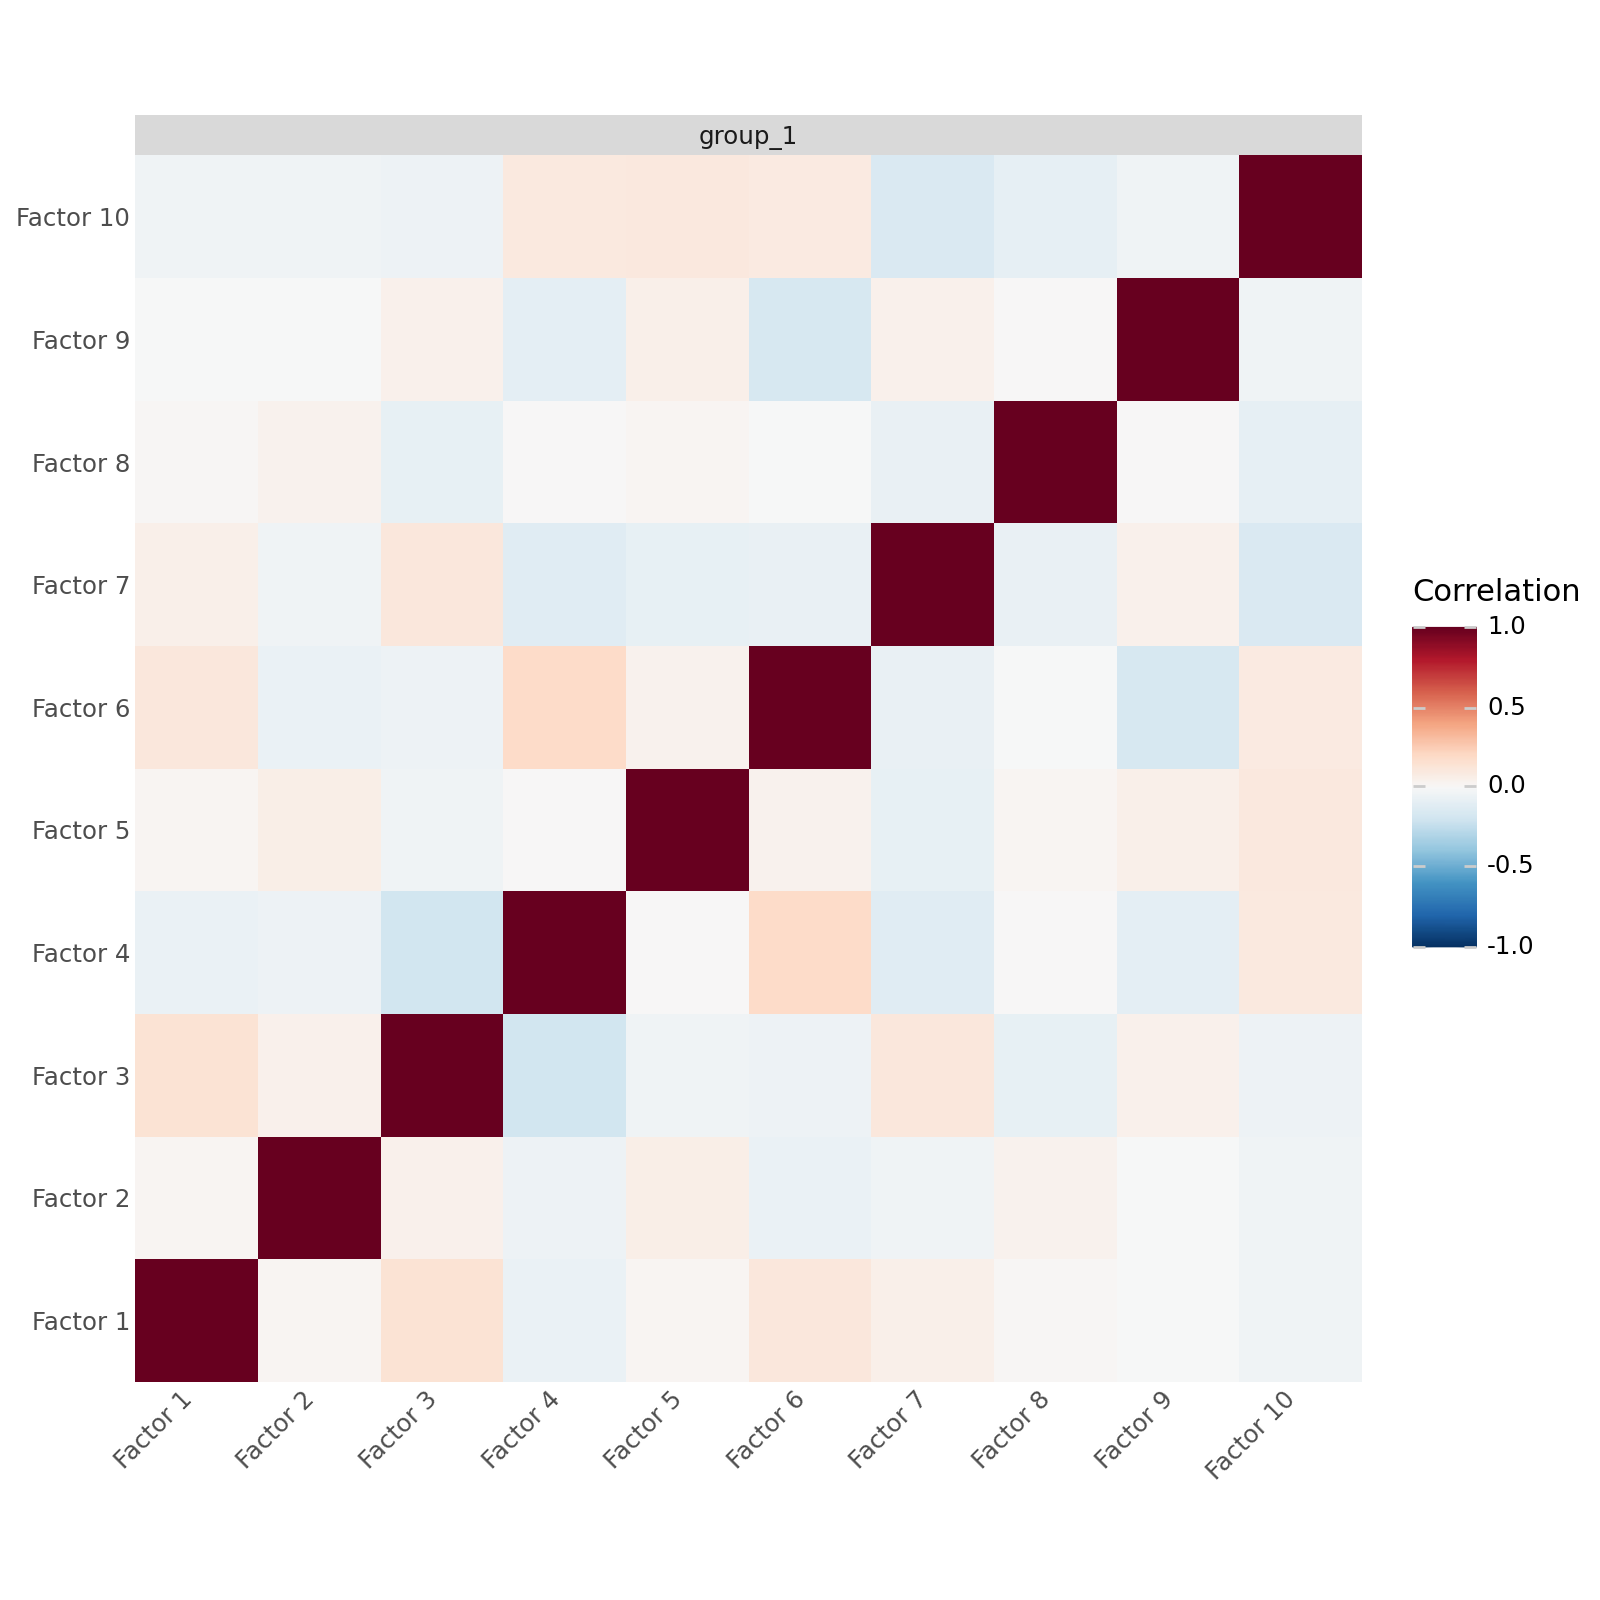

In [9]:
mfl.pl.factor_correlation(model)

In [ ]:
mfl.pl.factor(model, factor=4)

In [127]:
factor_corr = factors.corr()
factor_corr

,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5,Factor 6,Factor 7,Factor 8,Factor 9,Factor 10
Factor 1,1.000000,0.022626,0.146163,-0.068870,0.020929,0.114034,0.056675,0.009731,-0.000342,-0.041689
Factor 2,0.022626,1.000000,0.052565,-0.054350,0.064702,-0.068208,-0.040489,0.044104,-0.006696,-0.044694
Factor 3,0.146163,0.052565,1.000000,-0.195670,-0.040158,-0.047799,0.110888,-0.081532,0.050257,-0.051809
Factor 4,-0.068870,-0.054350,-0.195670,1.000000,0.006895,0.189004,-0.121866,0.001596,-0.100670,0.101445
Factor 5,0.020929,0.064702,-0.040158,0.006895,1.000000,0.042692,-0.081369,0.021748,0.060146,0.106992
Factor 6,0.114034,-0.068208,-0.047799,0.189004,0.042692,1.000000,-0.070839,-0.007581,-0.170707,0.086736
Factor 7,0.056675,-0.040489,0.110888,-0.121866,-0.081369,-0.070839,1.000000,-0.075610,0.054743,-0.153678
Factor 8,0.009731,0.044104,-0.081532,0.001596,0.021748,-0.007581,-0.075610,1.000000,0.006776,-0.088643
Factor 9,-0.000342,-0.006696,0.050257,-0.100670,0.060146,-0.170707,0.054743,0.006776,1.000000,-0.045024
Factor 10,-0.041689,-0.044694,-0.051809,0.101445,0.106992,0.086736,-0.153678,-0.088643,-0.045024,1.000000


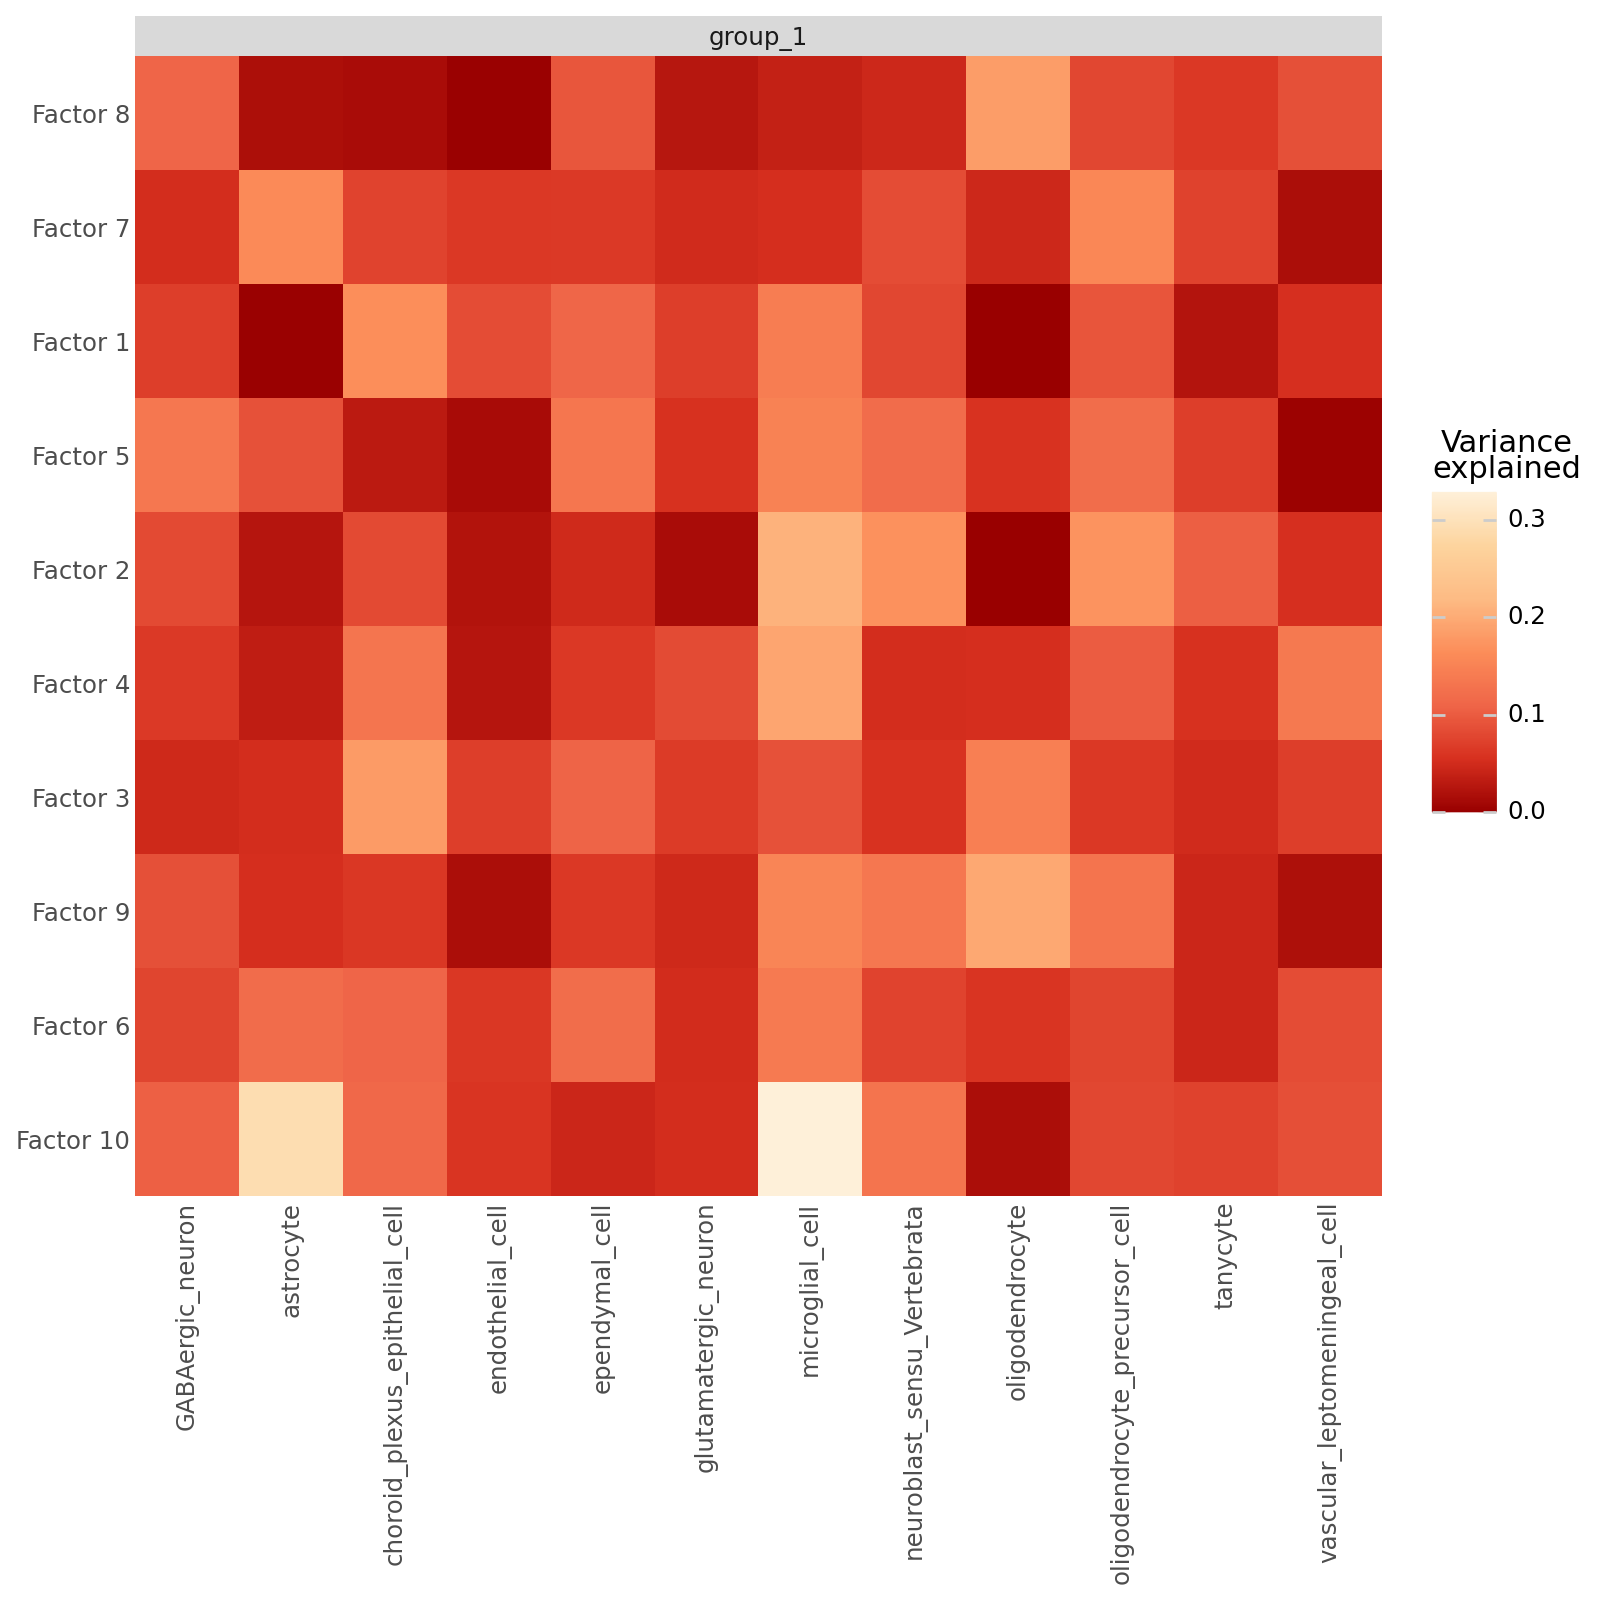

In [10]:
mfl.pl.variance_explained(model, figsize= (8,8))

## 2. Average R2

In [11]:
print(model.get_r2(total=True))

                                 group_1
glutamatergic_neuron            0.481457
tanycyte                        0.612436
neuroblast_sensu_Vertebrata     0.923099
GABAergic_neuron                0.783683
ependymal_cell                  0.889443
vascular_leptomeningeal_cell    0.736629
microglial_cell                 0.999997
choroid_plexus_epithelial_cell  0.813160
oligodendrocyte_precursor_cell  0.987767
astrocyte                       0.749038
oligodendrocyte                 0.852500
endothelial_cell                0.553297


In [25]:
r2 = model.get_r2(total=True)
r2["group_1"].mean()

np.float64(0.7818754362287995)

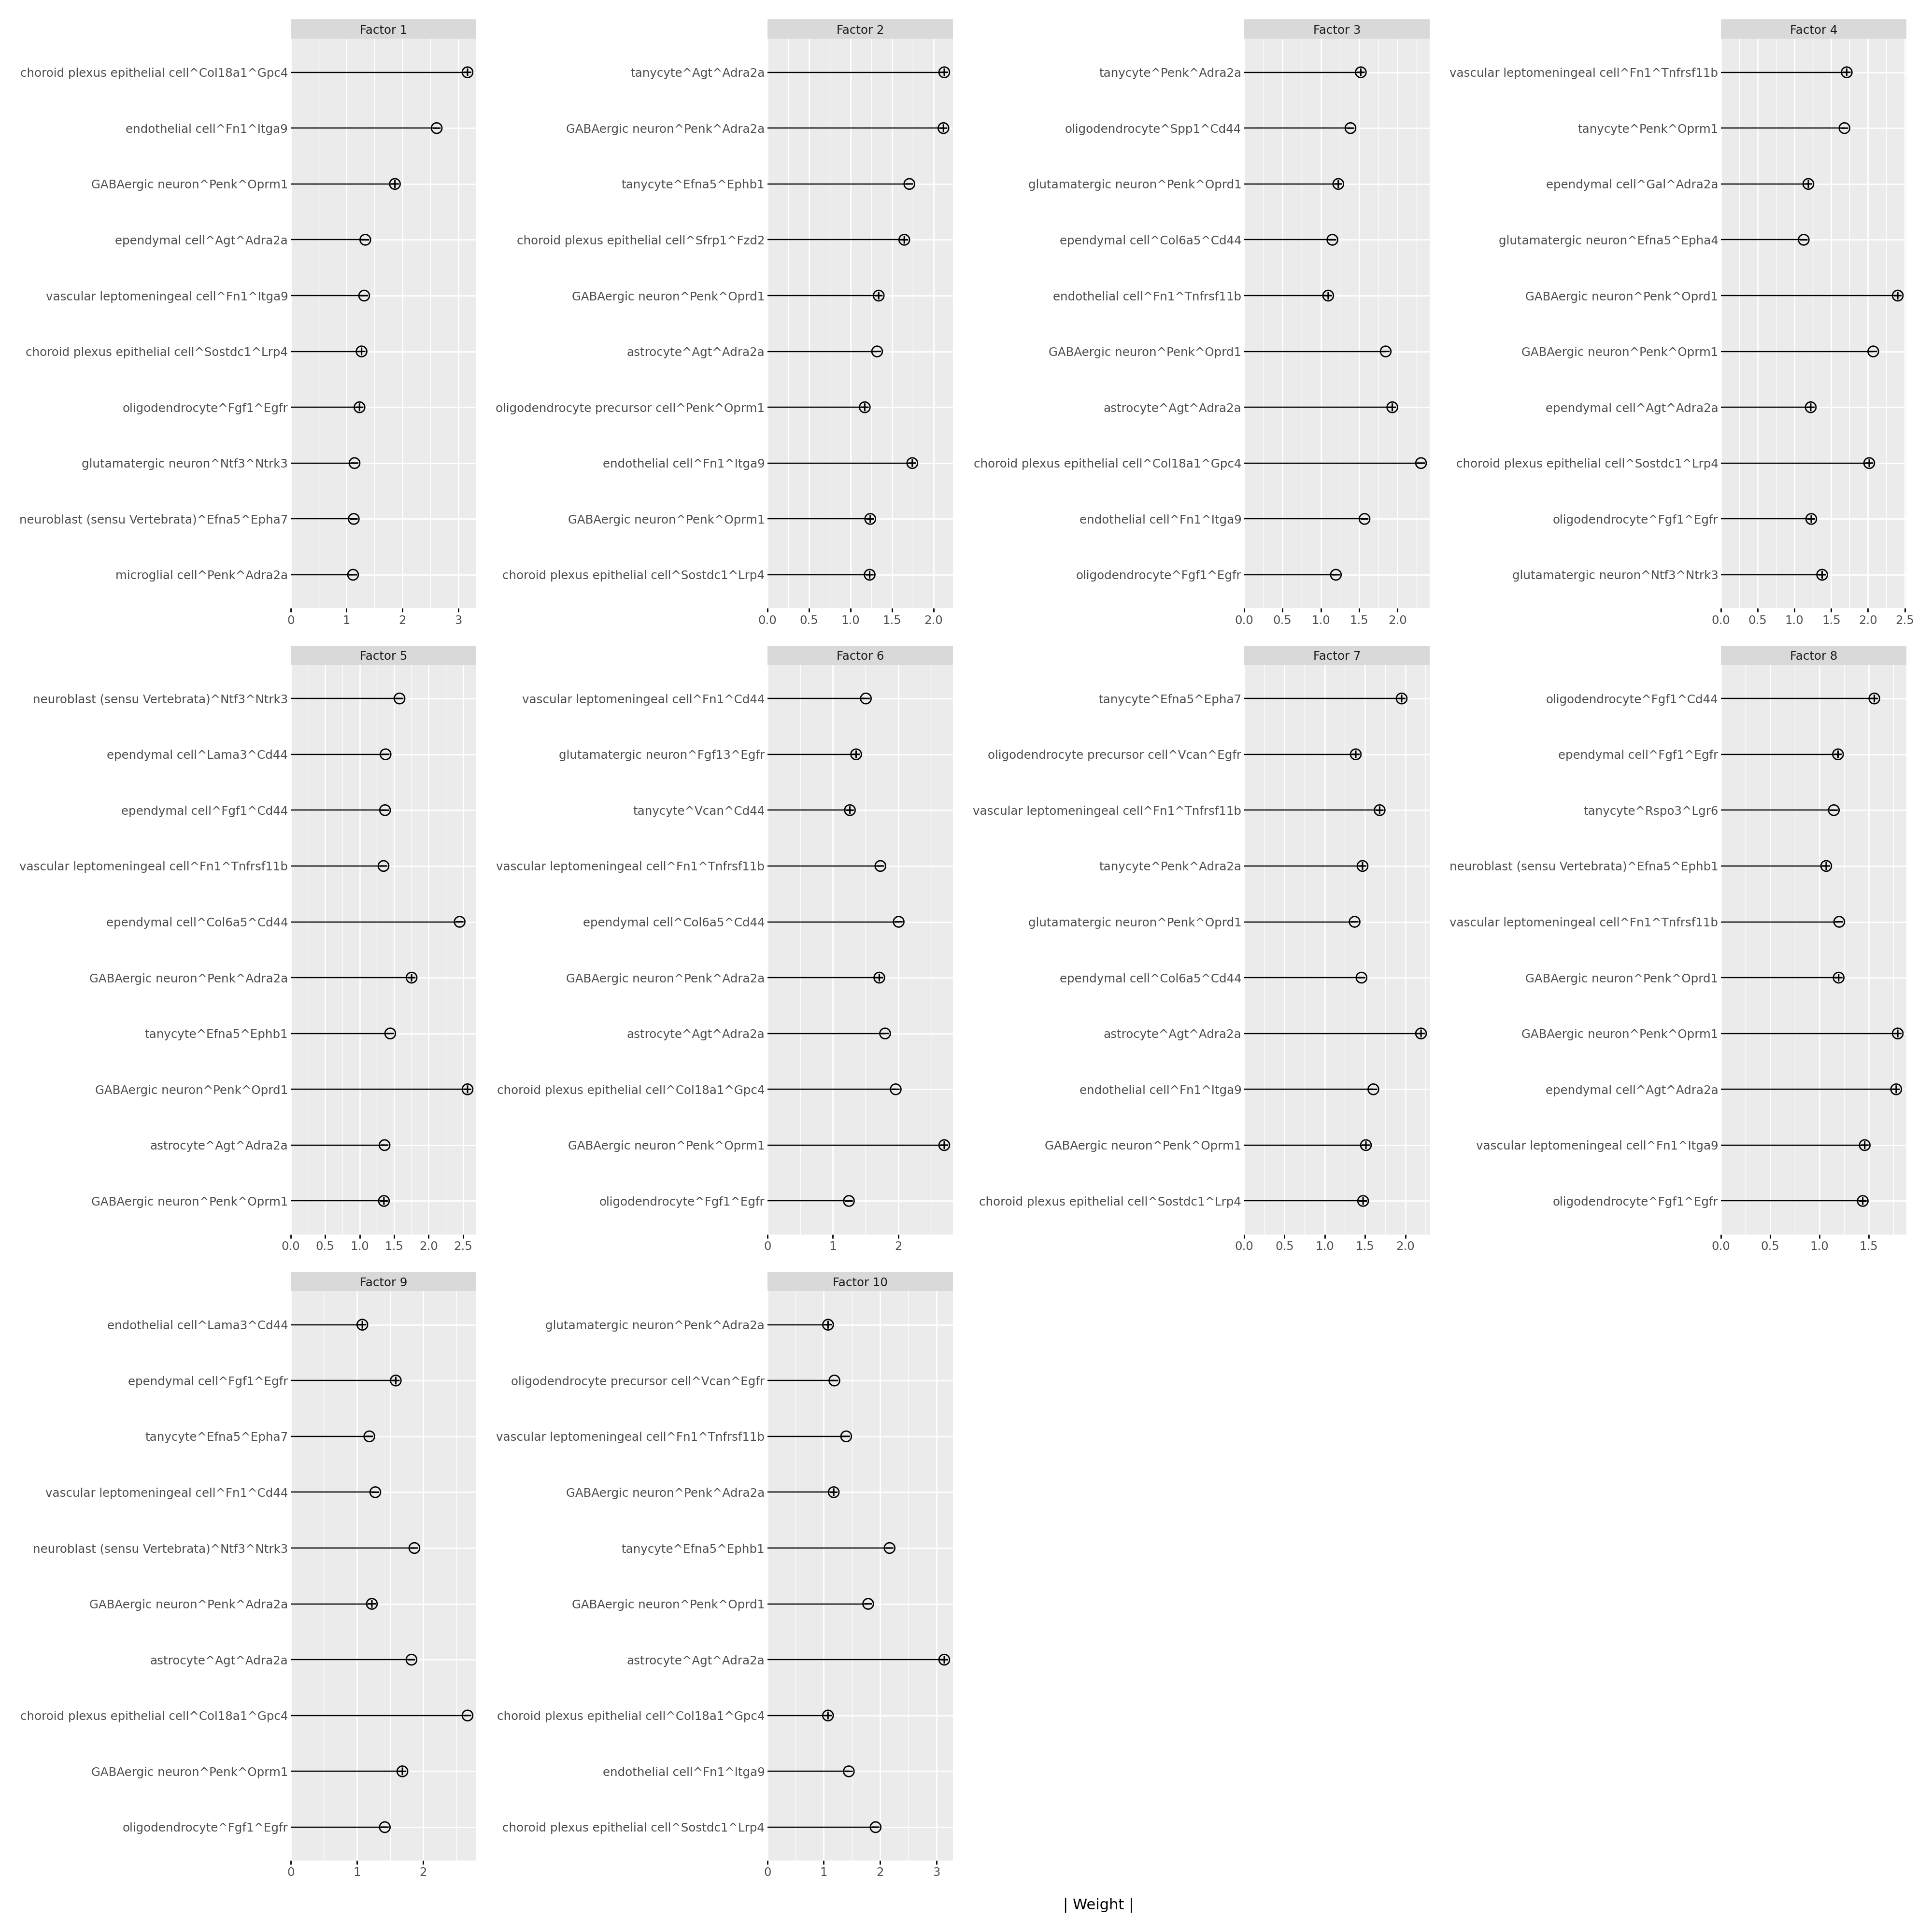

In [44]:
mfl.pl.top_weights(model, n_features=10, factors=None, figsize=(20, 20), nrow=None, ncol=None)

In [3]:
factors = model.get_factors()
factors = factors["group_1"]

In [4]:
merfish_path = Path("/g/stegle/aalsayah/repos/data/merfish")
lrdata = sc.read(merfish_path / "lrdata_animal2_C57BL6J-2.039.h5ad")

In [5]:
factors = factors.reindex(lrdata.obs.index)
factors

,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5,Factor 6,Factor 7,Factor 8,Factor 9,Factor 10
103576196949920497573001894272212144221,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
132302634259480526598156860055332604109,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
164492344227050668618415180651905305632,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
235161178942499950931130898972023464829,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
119950646828346183590260908810163002367,-2.585658,0.330648,1.617901,-1.654825,-1.714915,1.711689,1.010769,0.562593,1.406985,0.350748
...,...,...,...,...,...,...,...,...,...,...
30496178378309302787148079129820207902,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
42677744318756212167097224383169844563,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
67257148945622534963056180523530707821,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
70271787489108893818546054443003655152,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [131]:
lrdata.obs["factor10"] = factors["Factor 10"]

In [129]:
lrdata.obs.columns

Index(['donor_id', 'development_stage_ontology_term_id',
       'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id',
       'disease_ontology_term_id', 'tissue_ontology_term_id',
       'cell_type_ontology_term_id', 'assay_ontology_term_id',
       'suspension_type', 'cluster_id_transfer', 'subclass_transfer',
       'cluster_confidence_score', 'subclass_confidence_score',
       'high_quality_transfer', 'major_brain_region', 'ccf_region_name',
       'brain_section_label', 'tissue_type', 'is_primary_data', 'cell_type',
       'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity',
       'development_stage', 'observation_joinid', 'factor5', 'factor8', '10'],
      dtype='object')

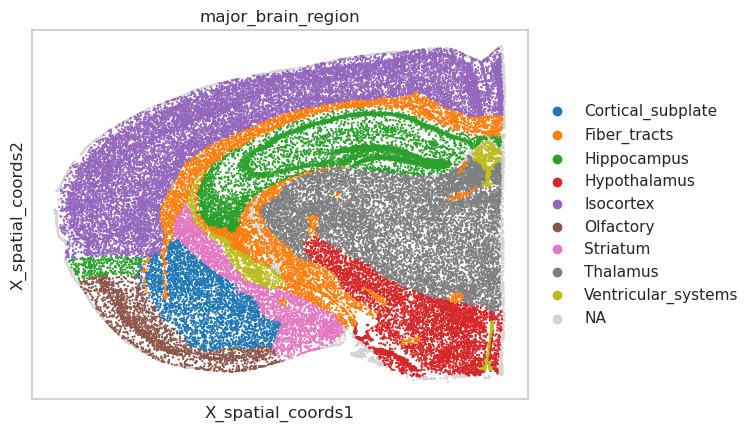

In [123]:
sc.pl.embedding(
    lrdata,
    basis="X_spatial_coords",         # or e.g. 'spatial', 'X_umap', etc.
    color=["major_brain_region"],     # list of metadata keys
    s=10,                             # point size
    cmap='viridis',                   # optional: color map
    ncols=2,
    wspace=0.4,                       # space between subplots
    show=True
)


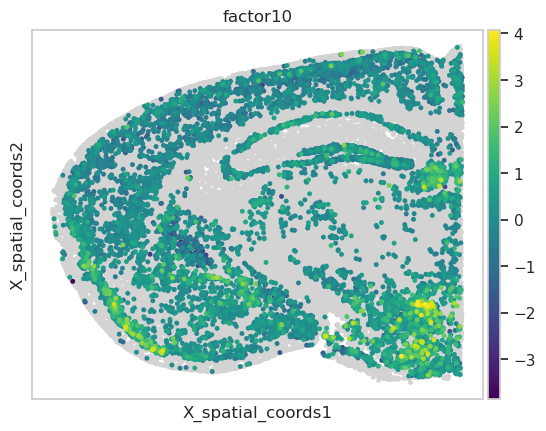

In [188]:
sc.pl.embedding(
    lrdata,
    basis="X_spatial_coords",         # or e.g. 'spatial', 'X_umap', etc.
    color=["factor10"],     # list of metadata keys
    s=50,                             # point size
    cmap='viridis',                   # optional: color map
    ncols=2,
    wspace=0.4,                       # space between subplots
    show=True
)

/scratch/jobs/39770668/ipykernel_397630/563422844.py:16: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


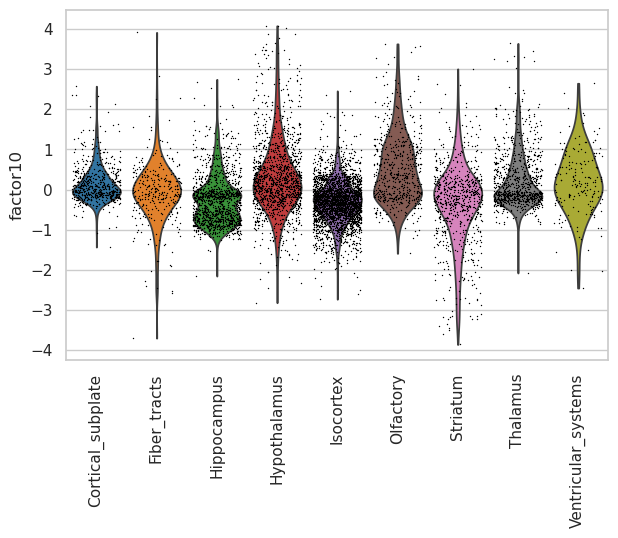

In [132]:
import scanpy as sc
import matplotlib.pyplot as plt

sc.pl.violin(
    lrdata,
    keys='factor10',
    groupby='major_brain_region',
    rotation=90,
    stripplot=True,
    jitter=0.4,
    multi_panel=False,
    show=False,       # allows you to modify before display
    legend=False      # disables the legend
)

plt.tight_layout()
plt.show()

In [133]:
lrdata2 = lrdata[~lrdata.obs["factor10"].isna(), :].copy()

In [134]:
coords = lrdata2.obsm["X_spatial_coords"]
values = lrdata2.obs["factor10"]

# Choose a threshold for "high" values, e.g. top 1% or > mean + 2*std
threshold = np.percentile(values, 99)
high_idx = values > threshold

# Get coordinates of high-value points
high_coords = coords[high_idx]
x_min, x_max = high_coords[:,0].min(), high_coords[:,0].max()
y_min, y_max = high_coords[:,1].min(), high_coords[:,1].max()

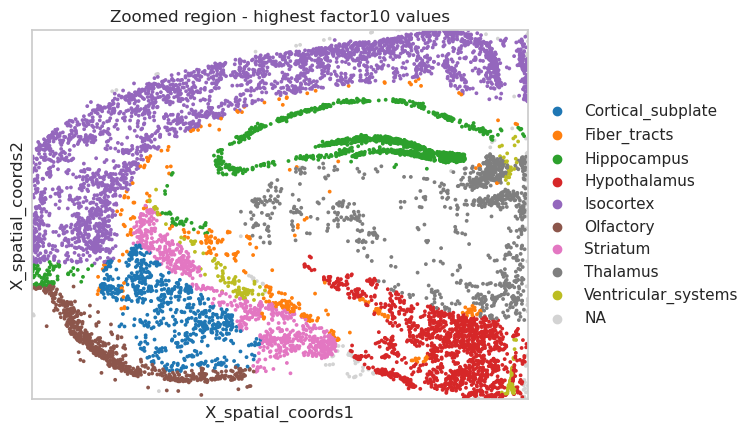

In [135]:
sc.pl.embedding(
    lrdata2,
    basis="X_spatial_coords",
    color=["major_brain_region"],
    s=30,
    ncols=2,
    cmap='viridis',
    show=False
)

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.title("Zoomed region - highest factor10 values")
plt.show()


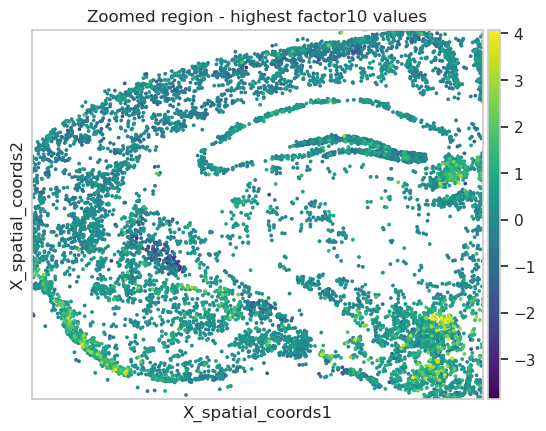

In [136]:
sc.pl.embedding(
    lrdata2,
    basis="X_spatial_coords",
    color=["factor10"],
    s=30,
    ncols=2,
    cmap='viridis',
    show=False
)

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.title("Zoomed region - highest factor10 values")
plt.show()

In [137]:
stats_factor = (
    lrdata2.obs
    .groupby(["major_brain_region", "cell_type"])["factor10"]
    .agg(["mean", "std"])
    .dropna()                # drop rows with any NaN in mean or std
    .sort_values("std")      # sort by std (ascending by default)
    .reset_index()
)
stats_factor

/scratch/jobs/39770668/ipykernel_397630/2030218746.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


,major_brain_region,cell_type,mean,std
0,Hippocampus,microglial cell,-0.138548,0.027848
1,Hippocampus,vascular leptomeningeal cell,-0.578201,0.091298
2,Cortical_subplate,endothelial cell,0.020900,0.110326
3,Fiber_tracts,microglial cell,0.279485,0.126156
4,Fiber_tracts,endothelial cell,0.014928,0.138891
...,...,...,...,...
77,Ventricular_systems,ependymal cell,-0.339345,1.135802
78,Fiber_tracts,ependymal cell,0.271541,1.147783
79,Striatum,GABAergic neuron,-0.555775,1.190596
80,Fiber_tracts,neuroblast (sensu Vertebrata),-0.416409,1.240109


In [138]:
# Compute mean, std, and count per (region, cell_type)
stats_factor = (
    lrdata2.obs
    .groupby(["major_brain_region", "cell_type"])["factor10"]
    .agg(["mean", "std", "count"])
    .dropna()
    .reset_index()
)

# Compute total cells per region
region_totals = (
    lrdata2.obs["major_brain_region"]
    .value_counts()
    .rename("region_total")
    .reset_index()
    .rename(columns={"index": "major_brain_region"})
)

# Merge totals back
stats_factor = stats_factor.merge(region_totals, on="major_brain_region", how="left")

# Compute fraction of cells in that region
stats_factor["cell_fraction_in_region"] = (
    stats_factor["count"] / stats_factor["region_total"]
)

# Sort by std (optional)
stats_factor = stats_factor.sort_values("std").reset_index(drop=True)

stats_factor

/scratch/jobs/39770668/ipykernel_397630/2710969098.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


,major_brain_region,cell_type,mean,std,count,region_total,cell_fraction_in_region
0,Hippocampus,microglial cell,-0.138548,0.027848,2,1311,0.001526
1,Hippocampus,vascular leptomeningeal cell,-0.578201,0.091298,2,1311,0.001526
2,Cortical_subplate,endothelial cell,0.020900,0.110326,2,631,0.003170
3,Fiber_tracts,microglial cell,0.279485,0.126156,3,319,0.009404
4,Fiber_tracts,endothelial cell,0.014928,0.138891,5,319,0.015674
...,...,...,...,...,...,...,...
77,Ventricular_systems,ependymal cell,-0.339345,1.135802,9,181,0.049724
78,Fiber_tracts,ependymal cell,0.271541,1.147783,5,319,0.015674
79,Striatum,GABAergic neuron,-0.555775,1.190596,405,713,0.568022
80,Fiber_tracts,neuroblast (sensu Vertebrata),-0.416409,1.240109,3,319,0.009404


In [139]:
stats_factor_f = stats_factor[stats_factor["cell_fraction_in_region"] >= 0.05].copy()

In [140]:
pairs = set(stats_factor_f[['major_brain_region', 'cell_type']].itertuples(index=False, name=None))

In [141]:
# Boolean mask: keep only obs rows whose (region, cell_type) pair is in allowed_pairs
mask = lrdata2.obs.apply(
    lambda row: (row['major_brain_region'], row['cell_type']) in pairs,
    axis=1
)

# Subset your AnnData
adata_sub = lrdata2[mask].copy()

/scratch/jobs/39770668/ipykernel_397630/2816610912.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/scratch/jobs/39770668/ipykernel_397630/2816610912.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



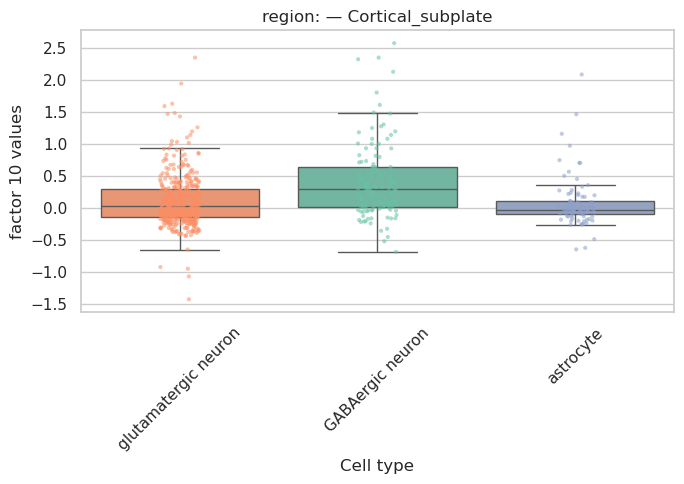

/scratch/jobs/39770668/ipykernel_397630/2816610912.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



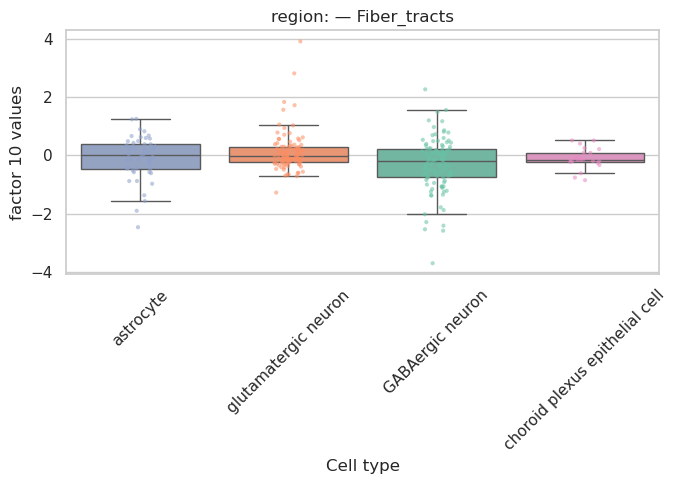

/scratch/jobs/39770668/ipykernel_397630/2816610912.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



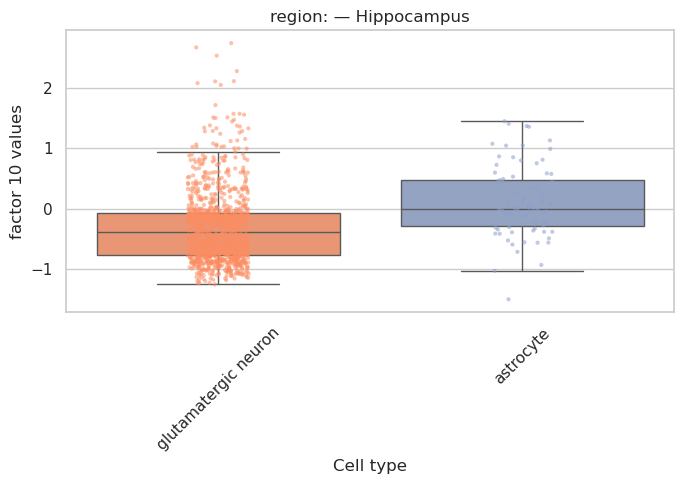

/scratch/jobs/39770668/ipykernel_397630/2816610912.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



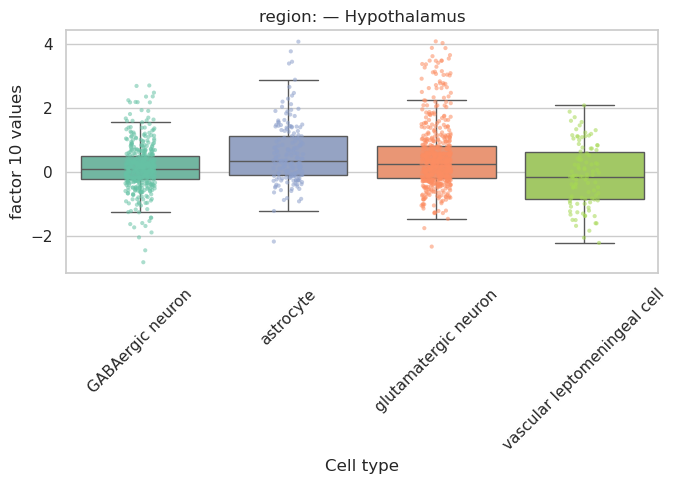

/scratch/jobs/39770668/ipykernel_397630/2816610912.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



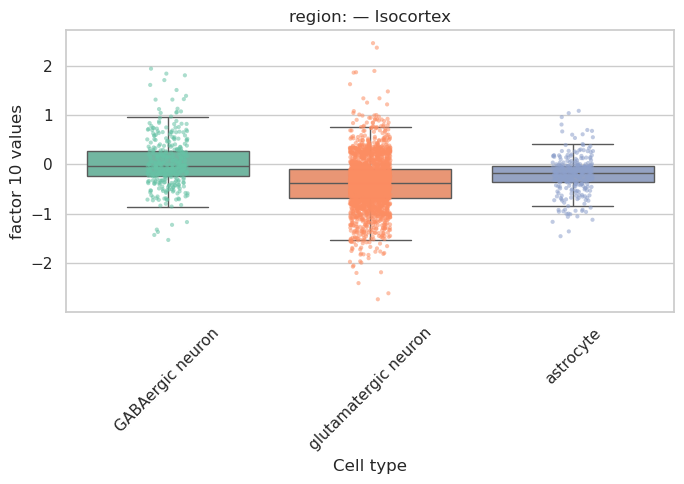

/scratch/jobs/39770668/ipykernel_397630/2816610912.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



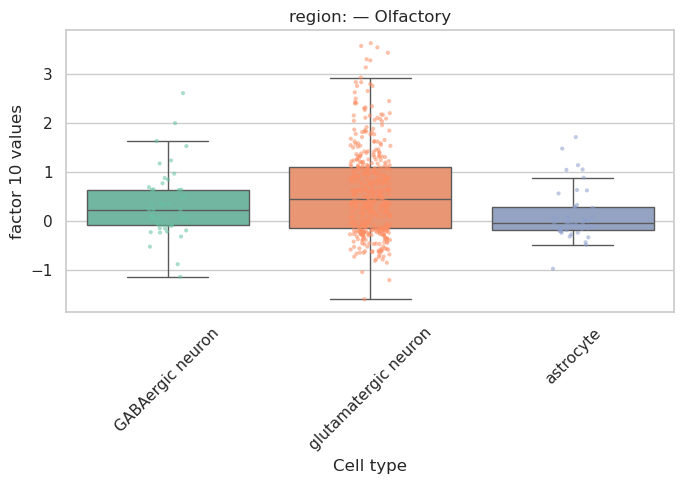

/scratch/jobs/39770668/ipykernel_397630/2816610912.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



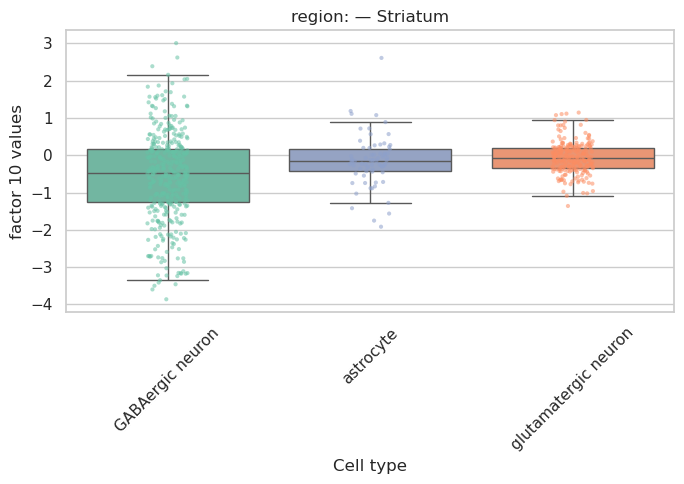

/scratch/jobs/39770668/ipykernel_397630/2816610912.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



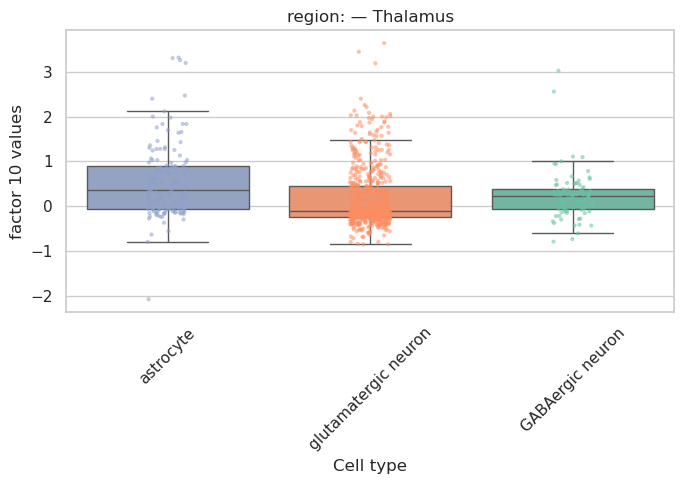

/scratch/jobs/39770668/ipykernel_397630/2816610912.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



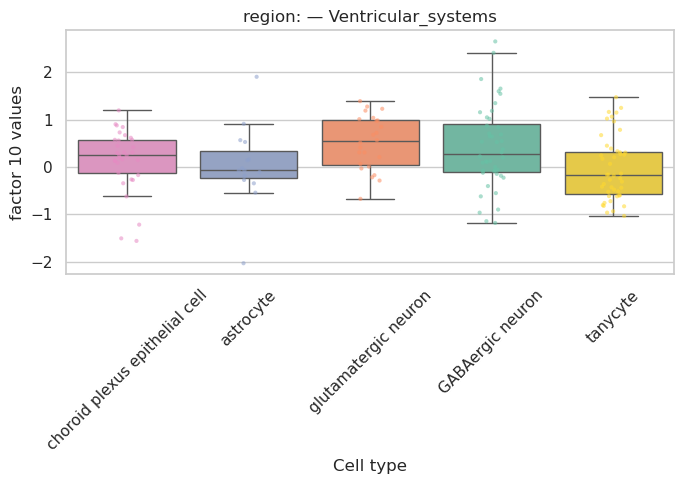

In [142]:
import seaborn as sns
import matplotlib.pyplot as plt

obs = adata_sub.obs.copy()

# consistent palette but only use existing cell types per region
all_cell_types = obs["cell_type"].unique()
palette = dict(zip(all_cell_types, sns.color_palette("Set2", n_colors=len(all_cell_types))))

for region, df in obs.groupby("major_brain_region", sort=True):
    present_cell_types = df["cell_type"].unique()

    plt.figure(figsize=(7, 5))
    ax = sns.boxplot(
        data=df,
        x="cell_type", y="factor10",
        order=present_cell_types,     # only those present
        palette=palette,
        showfliers=False
    )
    sns.stripplot(
        data=df,
        x="cell_type", y="factor10",
        order=present_cell_types,
        hue="cell_type",
        palette=palette,
        dodge=False,
        alpha=0.55, size=3,
        ax=ax, legend=False
    )

    ax.set_title(f"region: — {region}")
    ax.set_xlabel("Cell type")
    ax.set_ylabel("factor 10 values")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()


In [143]:
weights_dict= model.get_weights()

In [144]:
keys_to_keep = ["astrocyte"]

subset = {k: weights_dict[k] for k in keys_to_keep if k in weights_dict}


In [145]:
df = subset['astrocyte']
df

,astrocyte^Ntf3^Ntrk3,astrocyte^Gnb3^Gabbr2,astrocyte^Efna5^Epha4,astrocyte^Nts^Ntsr2,astrocyte^Spp1^S1pr1,astrocyte^Sfrp1^Fzd2,astrocyte^Efna5^Epha10,astrocyte^Efna5^Ephb1,astrocyte^Sostdc1^Lrp4,astrocyte^Tnc^Egfr,...,astrocyte^Wnt5a^Fzd5,astrocyte^Efna5^Epha3,astrocyte^Penk^Oprk1,astrocyte^Fn1^Itga9,astrocyte^Rspo1^Lgr5,astrocyte^Hgf^Cd44,astrocyte^Col6a1^Cd44,astrocyte^Fgf1^Cd44,astrocyte^Vcan^Cd44,astrocyte^Fn1^Cd44
Factor 1,-0.035625,5.104553e-06,2.927594e-01,0.000007,-0.391531,-0.122505,1.798141e-01,9.916712e-07,3.926376e-06,0.314737,...,2.834619e-06,-4.093565e-07,-0.000005,-0.513035,-2.221670e-05,3.022110e-01,5.061469e-01,0.576422,-7.496424e-07,0.667793
Factor 2,-0.036505,-5.928885e-06,6.025752e-01,-0.111575,0.000001,0.090845,1.262712e-01,2.042675e-02,-4.488688e-06,1.014937,...,-2.759637e-07,6.624452e-07,0.127310,0.237072,-2.128523e-06,-2.458031e-01,-3.474110e-01,-0.218992,-1.228673e-06,-0.452139
Factor 3,-0.002527,5.397818e-07,-9.047259e-02,0.000011,0.443383,0.000020,-2.863868e-01,-1.194584e-01,5.694140e-06,0.360531,...,-2.711832e-06,-1.016365e-01,0.000012,0.120270,-1.044405e-06,2.047701e-01,3.873241e-01,0.518565,-3.213821e-06,0.510460
Factor 4,0.000014,1.286063e-05,-4.727691e-01,-0.115656,-0.413187,-0.063678,-2.960216e-01,-1.190173e-01,-1.281381e-06,0.293878,...,-1.770750e-05,-7.567988e-02,0.000004,-0.406928,-1.248666e-05,-8.430897e-08,1.235063e-02,-0.024820,1.905867e-05,0.029510
Factor 5,0.000007,2.018595e-06,1.638400e-01,0.075436,-0.501304,-0.099418,-1.740314e-01,1.871621e-02,-8.272254e-07,-0.831635,...,4.990214e-06,2.159048e-06,0.059592,-0.235030,5.604878e-02,-4.770242e-06,-1.125548e-02,0.118115,-6.647883e-06,-0.011001
Factor 6,-0.000017,2.365074e-06,-1.089358e-01,-0.119886,0.166169,0.060295,-1.431084e-01,-1.050834e-01,2.402736e-06,1.046883,...,-8.688394e-06,3.147285e-06,-0.000008,0.478379,1.048307e-05,2.579266e-01,4.216867e-01,0.425084,1.729753e-05,0.522927
Factor 7,-0.007905,-6.491812e-02,-1.595885e-01,0.134602,-0.000003,0.059737,-1.041972e-01,-2.888832e-06,-1.964961e-06,0.070699,...,-5.369264e-07,-1.233383e-05,0.000009,0.273466,3.849269e-02,6.040559e-07,7.087978e-06,-0.181580,-3.257048e-06,0.000012
Factor 8,-0.000009,1.108015e-05,2.816690e-01,-0.146222,0.000003,0.000100,4.936236e-01,4.667093e-05,-2.410169e-05,-0.696582,...,-7.654826e-06,-5.045557e-06,0.613532,0.063261,-1.097158e-06,-4.520126e-05,2.979715e-05,-0.314836,-1.232216e-05,0.000010
Factor 9,-0.000002,-8.033558e-06,-9.264710e-07,-0.265983,0.309092,0.000010,-4.534968e-07,4.033966e-02,1.540336e-06,-0.038106,...,1.955026e-07,7.973485e-06,-0.312768,0.391077,-7.989692e-07,1.086168e-03,-3.322787e-07,0.000034,3.697910e-06,-0.000007
Factor 10,0.000005,5.551703e-06,3.433995e-01,-0.099691,-0.216006,-0.161319,1.827589e-01,4.813716e-06,-1.136204e-06,-0.572624,...,1.082731e-06,8.060021e-02,0.037435,-0.128467,2.631208e-06,8.153328e-02,1.258864e-01,0.202891,-2.234919e-06,0.150356


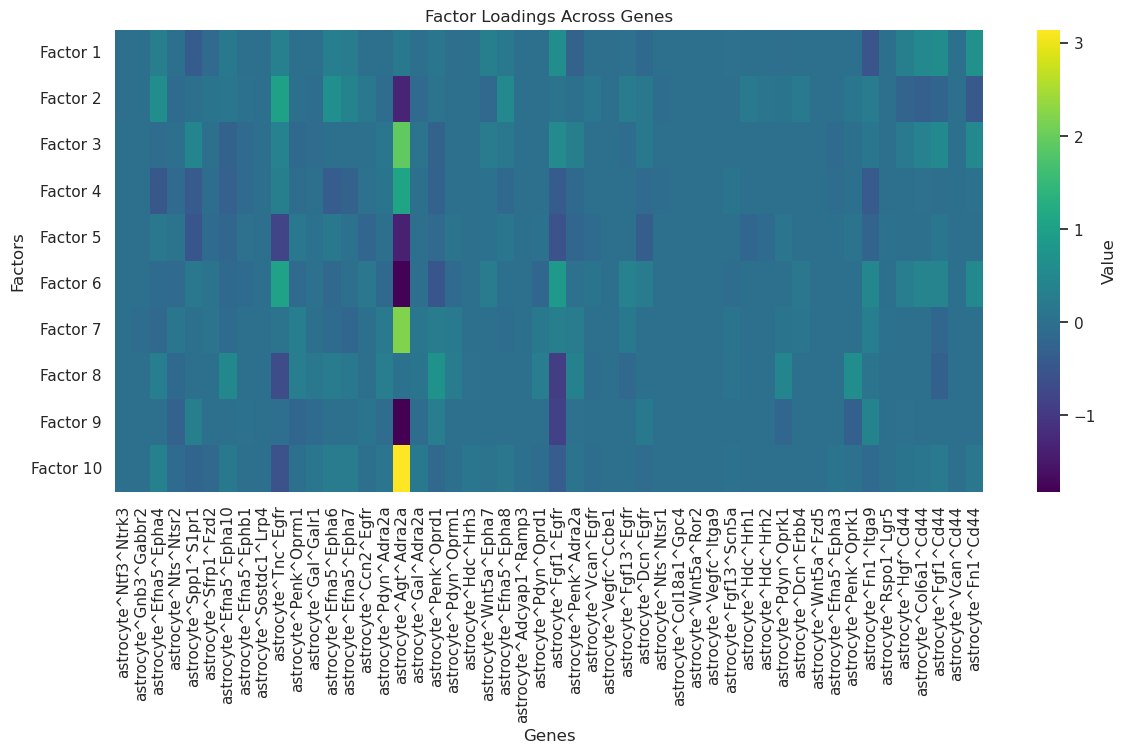

In [146]:
import matplotlib.pyplot as plt
import seaborn as sns  # optional, but great for heatmaps

plt.figure(figsize=(14, 6))
sns.heatmap(df, cmap="viridis", cbar_kws={'label': 'Value'})
plt.xlabel("Genes")
plt.ylabel("Factors")
plt.title("Factor Loadings Across Genes")
plt.show()


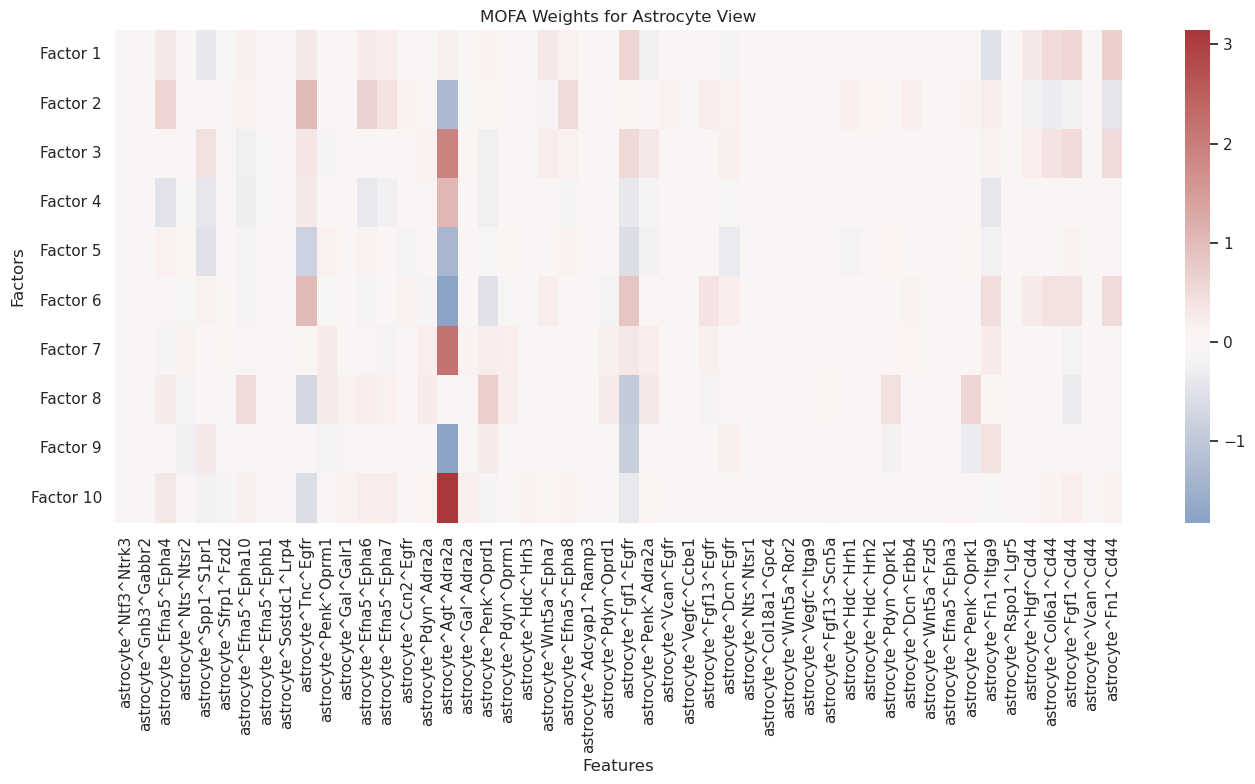

In [147]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))
sns.heatmap(df, cmap="vlag", center=0)
plt.title("MOFA Weights for Astrocyte View")
plt.xlabel("Features")
plt.ylabel("Factors")
plt.tight_layout()
plt.show()


In [250]:
factors = model.get_factors()
factors = factors["group_1"]

In [251]:
cell_types = lrdata.obs["cell_type"]
#tissue = lrdata.obs["tissue"]

In [252]:
df = factors.copy()
df['cell_type'] = cell_types
#df['tissue'] = tissue

In [253]:
df_melted = df.reset_index().melt(
    id_vars=['index', "cell_type"],
    value_vars=[f'Factor {i}' for i in range(1, 11)],
    var_name='Factor',
    value_name='Value'
)

In [254]:
df_melted

,index,cell_type,Factor,Value
0,12185986486062748399642964467627918512,glutamatergic neuron,Factor 1,-0.267860
1,56898090918706268322480378279645296213,glutamatergic neuron,Factor 1,0.116429
2,120259415432447893517416781425739794741,GABAergic neuron,Factor 1,1.336947
3,62415733978122634249512061004080784872,glutamatergic neuron,Factor 1,1.362108
4,102093083336931440857879796934957752261,glutamatergic neuron,Factor 1,1.827404
...,...,...,...,...
93795,300543435981200758297044048836374706712,GABAergic neuron,Factor 10,0.372146
93796,312945673217699486459993049617980646276,glutamatergic neuron,Factor 10,-0.545570
93797,116344495286861894462157516420223807276,vascular leptomeningeal cell,Factor 10,-0.307079
93798,17582231177180709444320157527078380982,astrocyte,Factor 10,-0.063481


/scratch/jobs/38879061/ipykernel_14419/1520418314.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


<Figure size 1400x600 with 0 Axes>

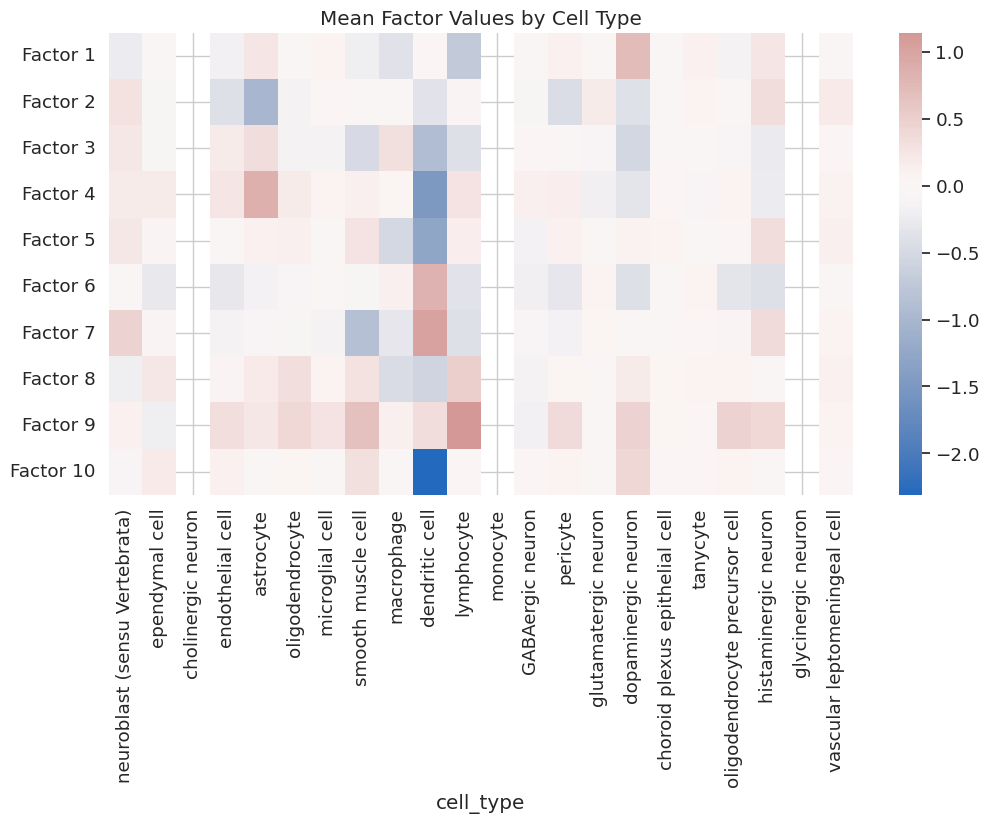

In [255]:
import seaborn as sns
import matplotlib.pyplot as plt

# Mean factor values per cell type
mean_factors = df.groupby('cell_type').mean().T

plt.figure(figsize=(12, 6))
sns.heatmap(mean_factors, cmap='vlag', center=0)
plt.title('Mean Factor Values by Cell Type')
plt.show()


## 3.Weights dist

In [125]:
weights_dict= model.get_weights()

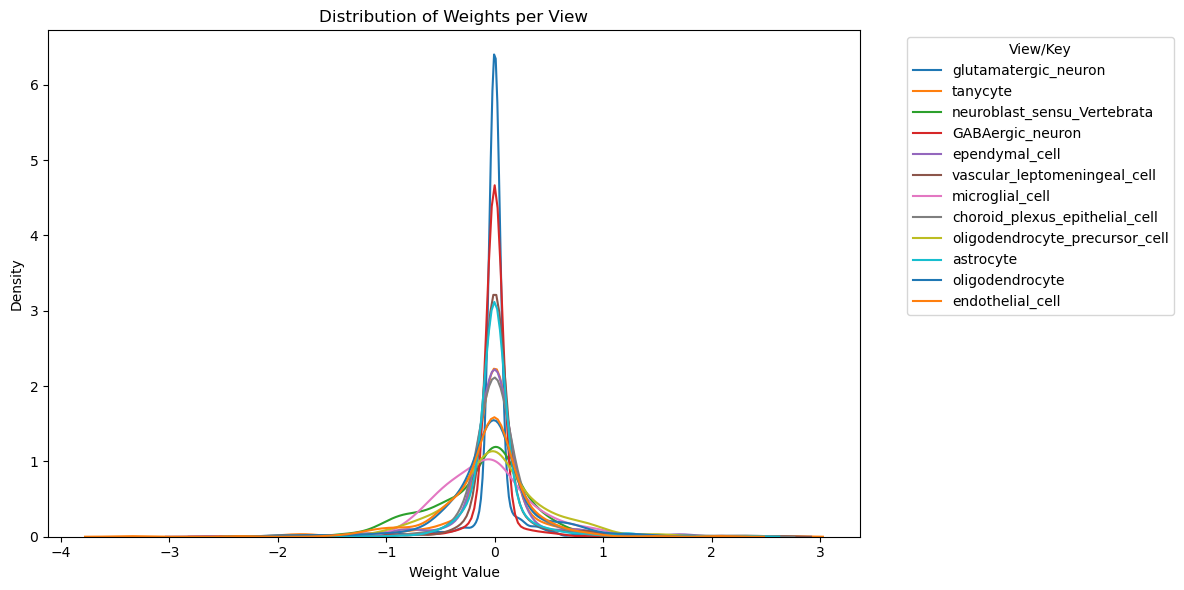

In [126]:
plt.figure(figsize=(12, 6))

# Loop through each view/key
for key, df in weights_dict.items():
    # Flatten all weights from that DataFrame into 1D array
    values = df.values.flatten()
    sns.kdeplot(values, label=key, fill=False)  # distribution curve

plt.title("Distribution of Weights per View")
plt.xlabel("Weight Value")
plt.ylabel("Density")
plt.legend(title="View/Key", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [127]:
#mfl.pl.all_weights(model_gp, views=['fib2'], figsize=(8,8), show_featurenames=True)
#mfl.pl.weights(model, n_features=10, views=["fib2"], factors=1, pointsize=2, figsize=(8,8))
#mfl.pl.top_weights(model, n_features=15, views="fib2", factors=1)

## 4. Heatmap (view x LR)

In [148]:
from string import ascii_uppercase
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

In [149]:
weights = model.get_weights()

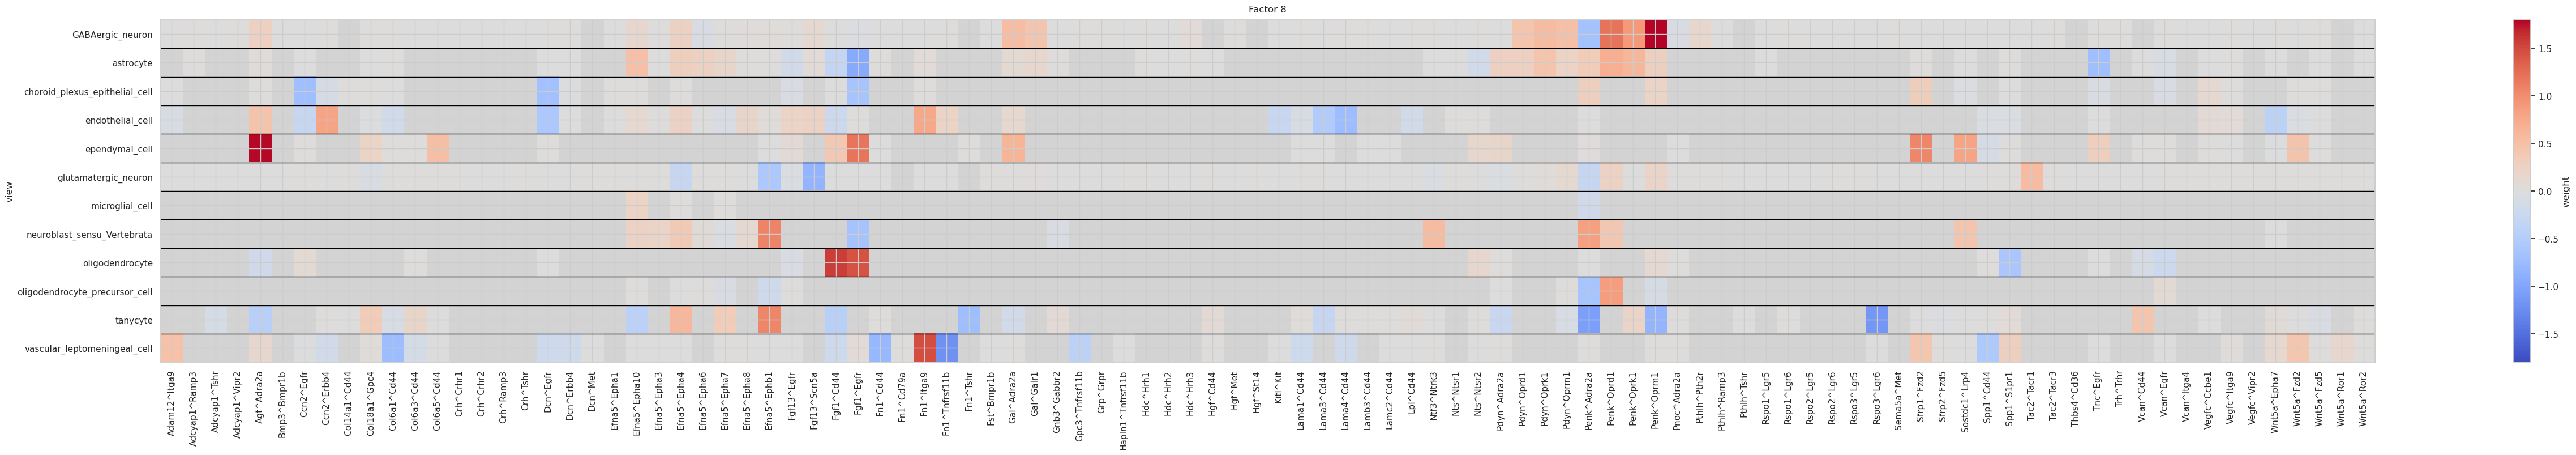

In [150]:
import re
from matplotlib.colors import TwoSlopeNorm

# choose the factor you want:
factor = 8

def resolve_factor_label(df, factor):
    """
    Return the exact row label in df.index for a given factor selector.
    Accepts: 3, "3", "Factor 3", "factor 03", etc.
    """
    idx_map = {str(idx).strip().lower(): idx for idx in df.index}
    key = str(factor).strip().lower()
    # exact match first
    if key in idx_map:
        return idx_map[key]
    # otherwise pull the first integer and try "Factor {n}"
    m = re.search(r'\d+', key)
    if m:
        candidate = f"factor {int(m.group())}"
        if candidate in idx_map:
            return idx_map[candidate]
    raise KeyError(f"Couldn't find factor '{factor}'. Available: {list(df.index)}")

rows, labels = [], []
for view, df in weights.items():
    row_label = resolve_factor_label(df, factor)
    s = df.loc[row_label].copy()
    s.index = ['^'.join(c.split('^')[1:]) for c in s.index]  # drop prefix before first ^
    rows.append(s)
    labels.append(view)

# assemble matrix (align columns across views)
all_cols = sorted({c for s in rows for c in s.index})
X = pd.DataFrame([s.reindex(all_cols) for s in rows], index=labels)

plt.figure(figsize=(0.5*X.shape[1] + 2, 0.6*X.shape[0] + 1))

# zero-centered diverging colormap
v = np.nanmax(np.abs(X.values))
norm = TwoSlopeNorm(vmin=-v, vcenter=0.0, vmax=v)
cmap = plt.get_cmap('coolwarm').copy()
cmap.set_bad('lightgray')  # NaNs

im = plt.imshow(np.ma.masked_invalid(X.values),
                aspect='auto', interpolation='nearest',
                cmap=cmap, norm=norm)

plt.yticks(range(X.shape[0]), X.index)
plt.xticks(range(X.shape[1]), X.columns, rotation=90)
plt.ylabel("view")
plt.colorbar(im, label="weight")
for r in range(1, X.shape[0]):
    plt.axhline(r - 0.5, color='black', lw=1)
plt.title(f"Factor {factor}", pad=10)  # shows "Factor 3" if you passed 3
plt.tight_layout()
plt.show()


# DR using factors values

In [151]:
factors = model.get_factors()
factors = factors["group_1"]

In [152]:
factors

,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5,Factor 6,Factor 7,Factor 8,Factor 9,Factor 10
12185986486062748399642964467627918512,-0.038700,-0.141872,0.235193,-0.512485,0.435524,-0.581932,0.268236,0.426881,-0.081160,-0.061678
56898090918706268322480378279645296213,-0.009337,-0.122596,-0.223246,-0.723521,-0.104783,-0.321245,0.460692,0.338865,0.325143,-0.520342
120259415432447893517416781425739794741,1.536977,-0.119793,-0.115059,-0.882041,-0.825341,0.346461,0.411705,-0.758100,-1.872880,0.550681
62415733978122634249512061004080784872,-0.033942,-0.176944,0.417583,-0.665058,-0.248777,-0.100015,0.771567,-0.699745,0.923949,0.376311
102093083336931440857879796934957752261,0.739455,-0.008331,1.121949,-1.328549,-0.904996,-0.467761,1.411118,-0.450379,0.711545,-1.172163
...,...,...,...,...,...,...,...,...,...,...
300543435981200758297044048836374706712,0.655393,-0.823529,-1.641060,0.221352,0.590440,-0.742963,1.534814,0.816014,0.230236,0.229216
312945673217699486459993049617980646276,0.652056,0.695160,0.353971,-0.678848,0.153742,0.327770,-0.199591,1.964227,1.360056,0.101048
116344495286861894462157516420223807276,-1.776412,0.458341,1.917300,1.364290,0.540474,-3.146276,1.503650,0.650487,-0.538746,0.013696
17582231177180709444320157527078380982,-0.588335,-0.298609,0.069764,-0.133692,-0.518582,-0.679361,-0.411517,-0.493615,-1.468660,-0.480397


### Load lrdata

In [133]:
data_path = Path("/g/stegle/aalsayah/repos/data/merfish")
lrdata = sc.read_h5ad(data_path/ "lrdata_animal2_C57BL6J-2.039.h5ad")

In [153]:
lv1 = lrdata.obs["major_brain_region"]

In [135]:
lv1 = lv1.loc[lv1.index.intersection(factors.index)]
lv1 = lv1.reindex(factors.index)
lv1.shape

(9380,)

In [154]:
lv2 = lrdata.obs["cell_type"]
lv2 = lv2.loc[lv2.index.intersection(factors.index)]
lv2 = lv2.reindex(factors.index)
lv2.shape

(9380,)

## UMAP

In [155]:
import umap.umap_ as umap
from sklearn.preprocessing import StandardScaler
import hdbscan

In [156]:
# --- Standardize ---
scaler = StandardScaler()
X = scaler.fit_transform(factors)

### higher-D

In [157]:
# --- UMAP for clustering (higher-D) ---
umap_clusters = umap.UMAP(
    n_components=10,
    n_neighbors=50,         
    min_dist=0.2,           
    metric="euclidean",      
    random_state=42
).fit_transform(X)

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


In [158]:
# --- HDBSCAN: start conservative ---
n = X.shape[0]
mcs = max(30, int(np.sqrt(n)))  
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=mcs,
    min_samples=None,               
    cluster_selection_method="eom",  
    cluster_selection_epsilon=0.05  
).fit(umap_clusters)

labels = clusterer.labels_
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
noise_rate = (labels == -1).mean()
print(f"clusters={n_clusters}, noise={noise_rate:.2%}")

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.


clusters=2, noise=0.00%


#### 2D UMAP

In [159]:
# --- 2D UMAP for visualization only ---
umap2 = umap.UMAP(
    n_components=2,
    n_neighbors=50,
    min_dist=0.2,
    metric="euclidean",
    random_state=42
).fit_transform(X)

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


In [160]:
df_umap = pd.DataFrame(umap2, columns=['UMAP1','UMAP2'], index=factors.index)
df_umap['Cluster'] = labels
df_umap['Conf'] = clusterer.probabilities_  # how confident each assignment is

#### Plot UMAP

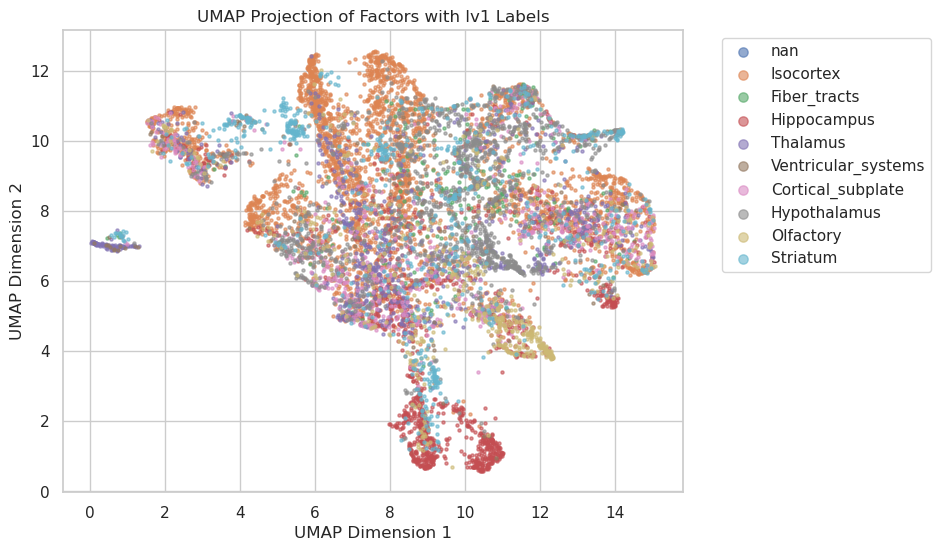

In [161]:
df_umap['Label'] = lv1.loc[factors.index].values

# Step 4: Plot UMAP with labels
plt.figure(figsize=(8,6))
for label in df_umap['Label'].unique():
    subset = df_umap[df_umap['Label'] == label]
    plt.scatter(subset['UMAP1'], subset['UMAP2'], s=5, alpha=0.6, label=label)

plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title("UMAP Projection of Factors with lv1 Labels")
plt.legend(markerscale=3, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

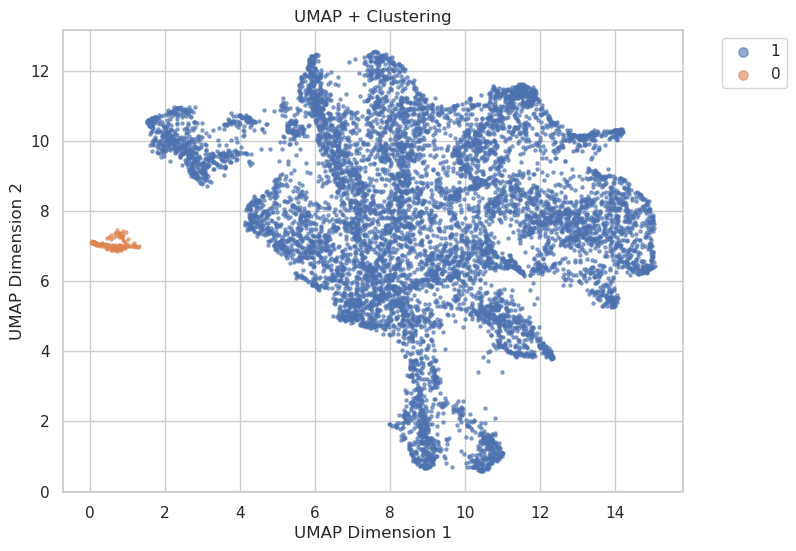

In [162]:
#Plot clusters

plt.figure(figsize=(8,6))
for label in df_umap['Cluster'].unique():
    subset = df_umap[df_umap['Cluster'] == label]
    plt.scatter(subset['UMAP1'], subset['UMAP2'], s=5, alpha=0.6, label=label)

plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title("UMAP + Clustering")
plt.legend(markerscale=3, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [163]:
lrdata.obs['F_Cluster'] = df_umap['Cluster'].reindex(lrdata.obs.index)

In [164]:
# Fill NaNs with default cluster value
lrdata.obs['F_Cluster'] = lrdata.obs['F_Cluster'].fillna(-1).astype(str)

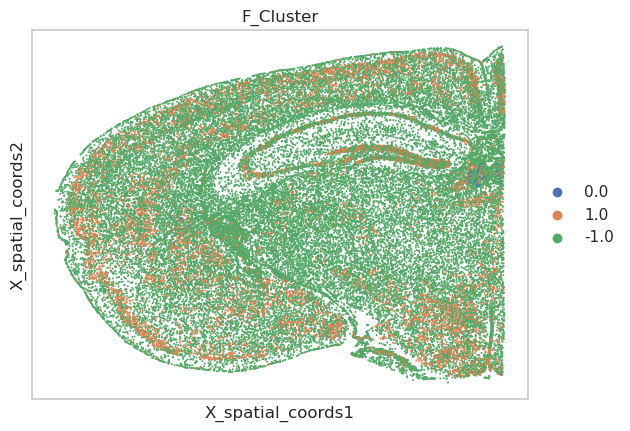

In [165]:
sc.pl.embedding(lrdata, basis="X_spatial_coords", color="F_Cluster", s=8)  # s = point size

# Regression Model

In [166]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [167]:
#get variables 
factors = model.get_factors() 
F = factors["group_1"]

#Get dependent var, change typ to any metadata column you wish to predict if factor values can predict
cell_names = F.index
cell_types = lrdata.obs["major_brain_region"]

# Step 1: Get overlapping indices (cells present in both)
common_cells = F.index.intersection(cell_types.index)

#Sort both
cell_types = cell_types.sort_index()
F=  F.sort_index()


# Step 2: Subset both to those common cells
F = F.loc[common_cells]
cell_types = cell_types.loc[common_cells]

In [168]:
from collections import Counter

# Count cells per class
counts = Counter(cell_types)
valid_classes = [cls for cls, n in counts.items() if n >= 2]

# Keep only those
mask = cell_types.isin(valid_classes)
F = F.loc[mask]
cell_types = cell_types.loc[mask]

In [169]:
# Combine features and labels into one DataFrame temporarily
combined = F.copy()
combined["major_brain_region"] = cell_types

# Drop any rows with NaNs (in features or cell_type)
combined = combined.dropna()

# Split them back out
F = combined.drop(columns=["major_brain_region"])
cell_types = combined["major_brain_region"]

In [170]:
len(F), len(cell_types)

(9181, 9181)

In [171]:
assert all(F.index == cell_types.index)

### Create X and Y objects

In [172]:
F

,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5,Factor 6,Factor 7,Factor 8,Factor 9,Factor 10
120259415432447893517416781425739794741,1.536977,-0.119793,-0.115059,-0.882041,-0.825341,0.346461,0.411705,-0.758100,-1.872880,0.550681
102093083336931440857879796934957752261,0.739455,-0.008331,1.121949,-1.328549,-0.904996,-0.467761,1.411118,-0.450379,0.711545,-1.172163
103270808480031989413265764865406850508,0.525915,-0.358756,-0.024541,0.761859,-0.516257,0.570875,-0.560510,-0.545444,-0.276211,-0.056041
112166717381054865156405891021945339091,0.207418,-0.021005,0.524210,-1.342884,-0.390129,-0.257907,1.162017,0.387598,0.633148,-0.846035
132681749461766417710527056770709490992,0.333710,0.116768,1.081585,-2.270067,-1.331531,-0.058763,2.040762,0.597325,0.843466,-1.104041
...,...,...,...,...,...,...,...,...,...,...
300543435981200758297044048836374706712,0.655393,-0.823529,-1.641060,0.221352,0.590440,-0.742963,1.534814,0.816014,0.230236,0.229216
312945673217699486459993049617980646276,0.652056,0.695160,0.353971,-0.678848,0.153742,0.327770,-0.199591,1.964227,1.360056,0.101048
116344495286861894462157516420223807276,-1.776412,0.458341,1.917300,1.364290,0.540474,-3.146276,1.503650,0.650487,-0.538746,0.013696
17582231177180709444320157527078380982,-0.588335,-0.298609,0.069764,-0.133692,-0.518582,-0.679361,-0.411517,-0.493615,-1.468660,-0.480397


In [173]:
cell_types

120259415432447893517416781425739794741       Isocortex
102093083336931440857879796934957752261       Isocortex
103270808480031989413265764865406850508       Isocortex
112166717381054865156405891021945339091       Isocortex
132681749461766417710527056770709490992       Isocortex
                                               ...     
300543435981200758297044048836374706712    Hypothalamus
312945673217699486459993049617980646276    Hypothalamus
116344495286861894462157516420223807276    Fiber_tracts
17582231177180709444320157527078380982        Olfactory
226146086476092669067549420887636486608       Olfactory
Name: major_brain_region, Length: 9181, dtype: category
Categories (9, object): ['Cortical_subplate', 'Fiber_tracts', 'Hippocampus', 'Hypothalamus', ..., 'Olfactory', 'Striatum', 'Thalamus', 'Ventricular_systems']

### Train multinomial logistic regression

In [174]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    F, cell_types, test_size=0.3, random_state=42, stratify=cell_types
)

In [175]:
clf = LogisticRegression(
    solver="lbfgs",
    max_iter=200,
    class_weight="balanced"
)

In [176]:
clf.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=200)

### Evaluate the model

In [177]:
# Evaluate
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.42540834845735026

Classification Report:
                      precision    recall  f1-score   support

  Cortical_subplate       0.20      0.46      0.28       189
       Fiber_tracts       0.07      0.14      0.09        96
        Hippocampus       0.62      0.48      0.54       394
       Hypothalamus       0.46      0.35      0.40       413
          Isocortex       0.77      0.52      0.62       954
          Olfactory       0.39      0.44      0.41       177
           Striatum       0.21      0.27      0.24       214
           Thalamus       0.36      0.37      0.37       264
Ventricular_systems       0.07      0.19      0.11        54

           accuracy                           0.43      2755
          macro avg       0.35      0.36      0.34      2755
       weighted avg       0.52      0.43      0.46      2755



### AUC

In [178]:
from sklearn.metrics import roc_auc_score, roc_curve

#### 1. If threr are 2 classes only (REF vs. CRC)

In [179]:
# Get predicted probabilities for the positive class (assume label "232_REF" is positive)
y_pred_proba = clf.predict_proba(X_test)[:, 1]

# Calculate AUC
auc = roc_auc_score(y_test, y_pred_proba)
print("AUC:", auc)


fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba, pos_label="222_REF")
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

ValueError: multi_class must be in ('ovo', 'ovr')

#### 2. If classes are more than 2:

In [180]:
# Get class probabilities 
y_proba = clf.predict_proba(X_test)   # shape = (n_samples, 3)

# Compute macro-average AUC (each class equally weighted, good default)
auc_macro = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")
print(f"Multiclass ROC AUC (OvR, macro): {auc_macro:.4f}")

# You could also try weighted averaging (weights by class support):
auc_weighted = roc_auc_score(y_test, y_proba, multi_class="ovr", average="weighted")
print(f"Multiclass ROC AUC (OvR, weighted): {auc_weighted:.4f}")


Multiclass ROC AUC (OvR, macro): 0.7567
Multiclass ROC AUC (OvR, weighted): 0.7963


# Spatial accuracy benchmark


Accuracy vs. ground truth annotations: NMI (normalized mutual information).

Spatial continuity/compactness: ASW (silhouette).

ARI

In [ ]:
from scipy.spatial import *
from sklearn.preprocessing import *

from sklearn.metrics import *
from scipy.spatial.distance import *

ASW: Silhouette score of all data points, which quantifies how well clusters are separated

In [ ]:
def compute_ASW(adata, pred_key, spatial_key='spatial'):
    d = squareform(pdist(adata.obsm[spatial_key]))  # pairwise distance matrix
    return silhouette_score(
        X=d,
        labels=adata.obs[pred_key],
        metric='precomputed'
    )

Remove NA


In [ ]:
lrdata_clean = lrdata[~lrdata.obs["Cluster"].isna()].copy()


Remove noise cluster


In [ ]:
# Keep only rows where Cluster != -1
lrdata_no_noise = lrdata_clean[lrdata_clean.obs["Cluster"] != -1].copy()

## Compute ASW


In [ ]:
compute_ASW(lrdata_no_noise, "Cluster", "spatial")


## NMI

In [ ]:
lrdata_clean2 = lrdata_no_noise[~lrdata_no_noise.obs["ist"].isna()].copy()
normalized_mutual_info_score(lrdata_clean2.obs["ist"],lrdata_clean2.obs["Cluster"])



## ARI

In [ ]:
adjusted_rand_score(lrdata_clean2.obs["typ"],lrdata_clean2.obs["Cluster"])
